# 🧠 임베딩(Embedding) 입문
### — 자연어를 숫자로 이해하는 AI의 언어 —

---

## 📋 학습 목표

이 노트북의 흐름

1. **인코딩 → 벡터화 → 임베딩** 개념의 차이와 발전 과정
2. 임베딩에 필요한 **수학적 기초** (벡터, 유사도)
3. **최신 LLM 임베딩 모델** 사용법 (sentence-transformers)
4. 임베딩의 실제 활용 — **유사도 검색**, **클러스터링**, **시각화**

🖥 **Google Colab**에서 실행 권장!

---

## 📚 목차

| 파트 | 내용 |
|------|------|
| **Part 0** | 환경 설정 |
| **Part 1** | 개념 이해 — 인코딩, 벡터화, 임베딩 |
| **Part 2** | 수학 기초 — 벡터와 유사도 |
| **Part 3** | 실습 — sentence-transformers 임베딩 |
| **Part 4** | 활용 1 — 의미 기반 유사도 검색 |
| **Part 5** | 활용 2 — 텍스트 클러스터링 |
| **Part 6** | 활용 3 — 임베딩 시각화 (t-SNE) |

---
# Part 0. 환경 설정

실습에 필요한 라이브러리를 설치합니다.

In [1]:
# Colab / 로컬 환경 공통 설치
!pip install -q sentence-transformers numpy matplotlib scikit-learn pandas

# Colab 한글 폰트 설치 (로컬에서는 자동 스킵)
import subprocess, sys
try:
    import google.colab  # Colab 환경 감지
    subprocess.run(['apt-get', 'install', '-y', '-q', 'fonts-nanum'], check=True)
    print('✅ Colab 환경 — 나눔폰트 설치 완료')
except ImportError:
    print('✅ 로컬 환경 — 별도 폰트 설치 불필요')

✅ 로컬 환경 — 별도 폰트 설치 불필요


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
from sklearn.metrics.pairwise import cosine_similarity
import warnings, platform
warnings.filterwarnings('ignore')

# ── 한글 폰트 설정 ──────────────────────────────────────
import matplotlib.font_manager as fm

def setup_korean_font():
    # Colab (Linux): 나눔고딕
    if platform.system() == 'Linux':
        font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
        import os
        if os.path.exists(font_path):
            fm.fontManager.addfont(font_path)
            font_name = fm.FontProperties(fname=font_path).get_name()
            plt.rcParams['font.family'] = font_name
            return font_name
    # macOS
    if platform.system() == 'Darwin':
        plt.rcParams['font.family'] = 'AppleGothic'
        return 'AppleGothic'
    # Windows
    if platform.system() == 'Windows':
        plt.rcParams['font.family'] = 'Malgun Gothic'
        return 'Malgun Gothic'
    return 'default'

font_name = setup_korean_font()
plt.rcParams['axes.unicode_minus'] = False
print(f'환경 설정 완료  |  사용 폰트: {font_name}')


환경 설정 완료  |  사용 폰트: AppleGothic


---
# Part 1. 개념 이해 — 인코딩, 벡터화, 임베딩

## 🤔 컴퓨터는 어떻게 언어를 이해할까?

컴퓨터는 오직 **숫자(0과 1)만** 처리할 수 있습니다.  
그렇다면 "사랑", "행복", "슬픔" 같은 말을 컴퓨터에게 이해시키려면 어떻게 해야 할까요?

역사적으로 이 문제를 해결한 방법이 3단계로 발전했습니다.

---

## 1️⃣ 인코딩 (Encoding) — "단순히 번호 붙이기"

가장 단순한 방법: **각 글자나 단어에 숫자 번호를 붙이기**

```
가 → 0
나 → 1  
다 → 2
...
```

이것이 바로 **ASCII 코드**, **유니코드** 같은 문자 인코딩입니다.  

> ⚠ **문제점**: 번호만 붙인 것이라 '의미'가 없습니다.  
> "사랑(3)"과 "애정(4)"은 1 차이나지만, "사랑(3)"과 "가나다(0,1,2)"보다 더 가깝다는 것을 알 수 없어요.

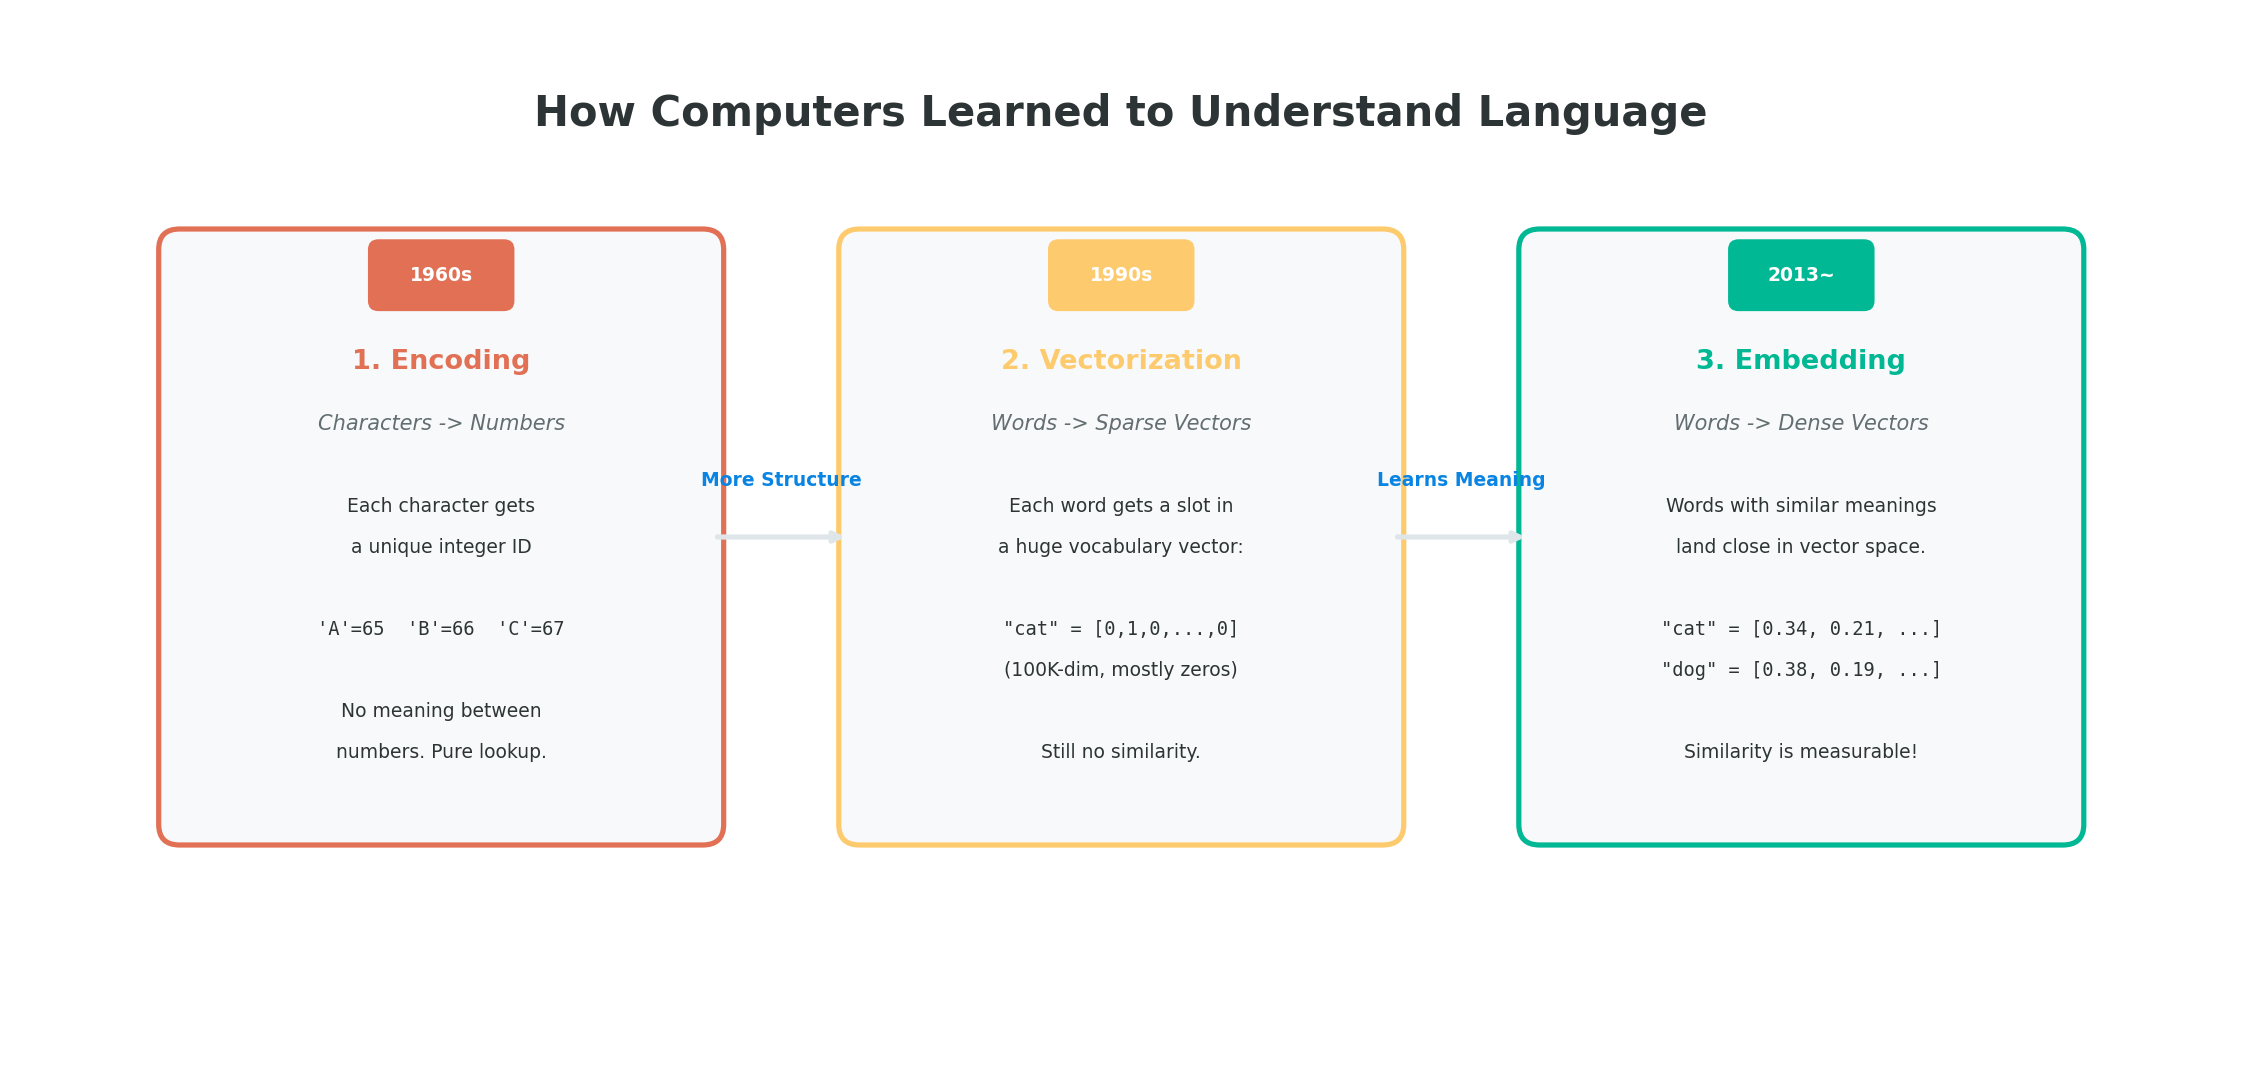

*▲ 컴퓨터가 언어를 이해하는 방법의 3단계 발전*

---


In [3]:
# 인코딩 예시: 문자를 숫자로 변환
text = "Hello"

print("=== 문자 인코딩 (ASCII) ===")
print(f"원본 텍스트: '{text}'")
print()

for char in text:
    print(f"  '{char}' → ASCII 코드: {ord(char)}")

print()
print("한글 예시:")
for char in "사랑":
    print(f"  '{char}' → 유니코드: {ord(char)} (U+{ord(char):04X})")

=== 문자 인코딩 (ASCII) ===
원본 텍스트: 'Hello'

  'H' → ASCII 코드: 72
  'e' → ASCII 코드: 101
  'l' → ASCII 코드: 108
  'l' → ASCII 코드: 108
  'o' → ASCII 코드: 111

한글 예시:
  '사' → 유니코드: 49324 (U+C0AC)
  '랑' → 유니코드: 46993 (U+B791)


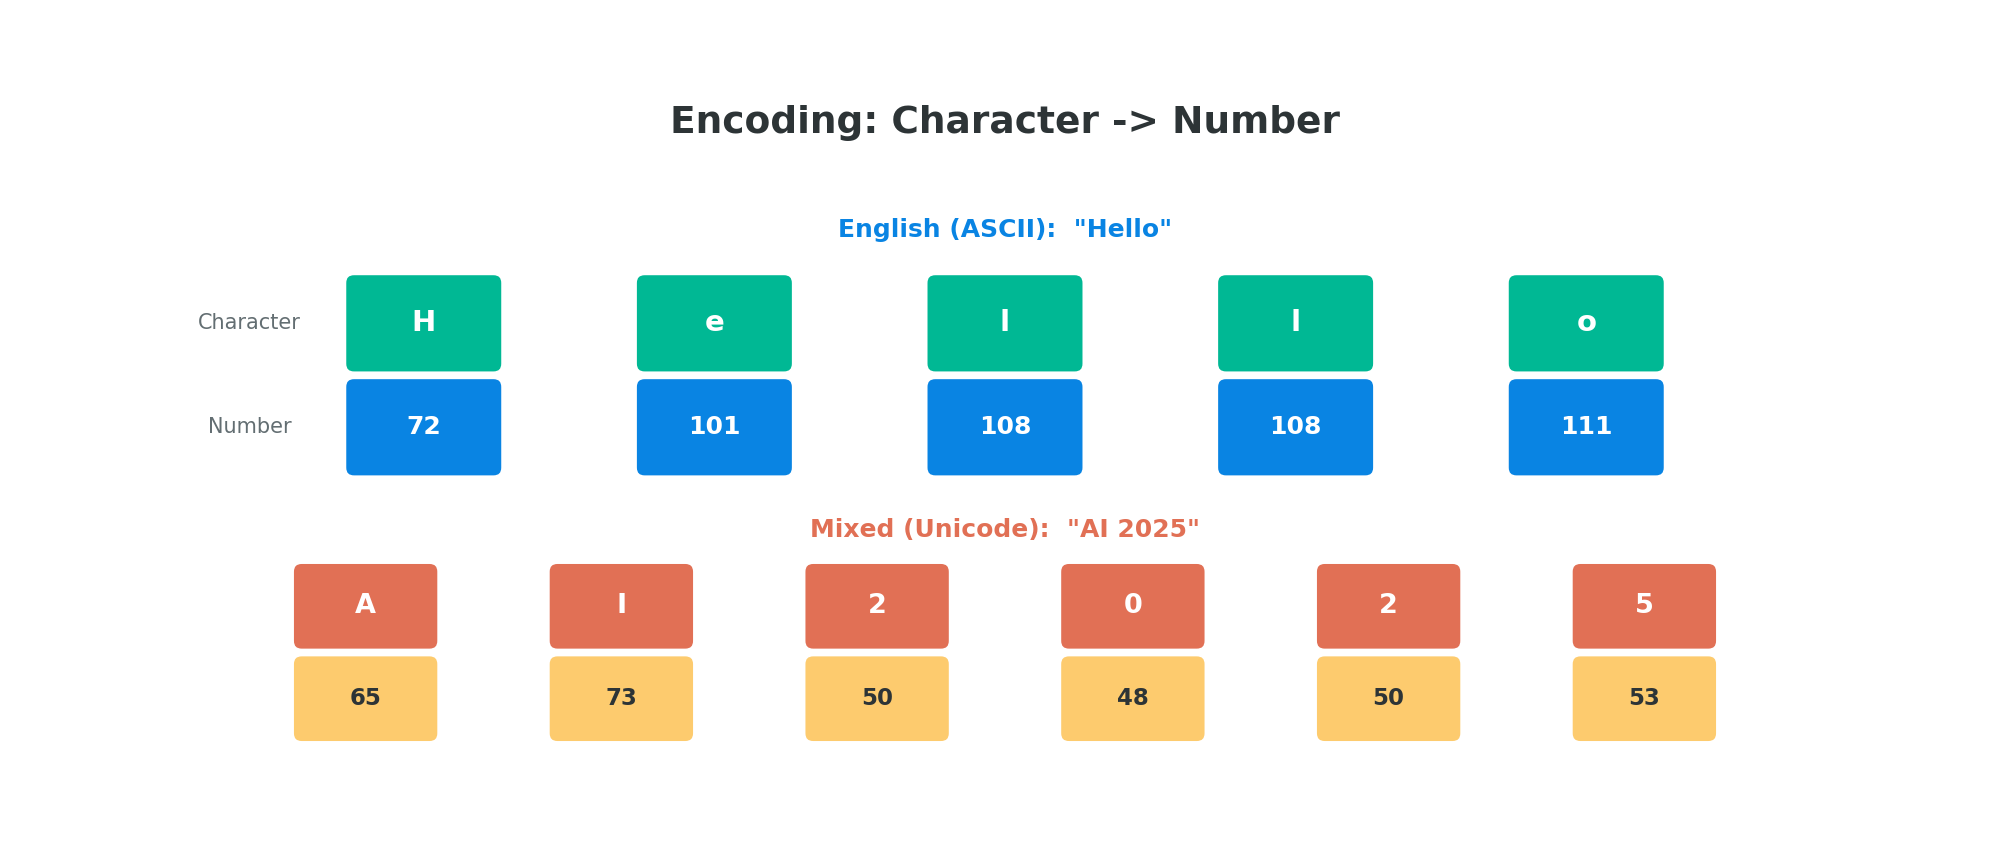

*▲ 인코딩: 각 글자는 숫자 코드를 부여받지만 의미는 없음*


## 2️⃣ 벡터화 (Vectorization) — "단어를 목록으로 표현하기"

인코딩의 한계를 넘기 위해, **단어들의 목록을 만들고 각 단어가 등장하는지 표시**하는 방법이 등장했습니다.

### 🗳 원-핫 인코딩 (One-Hot Encoding)

단어 사전을 만들고, 해당 단어 위치에만 1, 나머지는 0을 넣는 방식:

```
단어 사전: [강아지, 고양이, 사랑, 귀엽다]

"강아지" → [1, 0, 0, 0]
"고양이" → [0, 1, 0, 0]
"사랑"   → [0, 0, 1, 0]
```

> ⚠ **문제점**: 단어가 10만 개라면 [0,0,...,1,...,0] — 10만 칸짜리 배열!  
> 게다가 "강아지"와 "개"가 비슷하다는 것을 여전히 모릅니다.

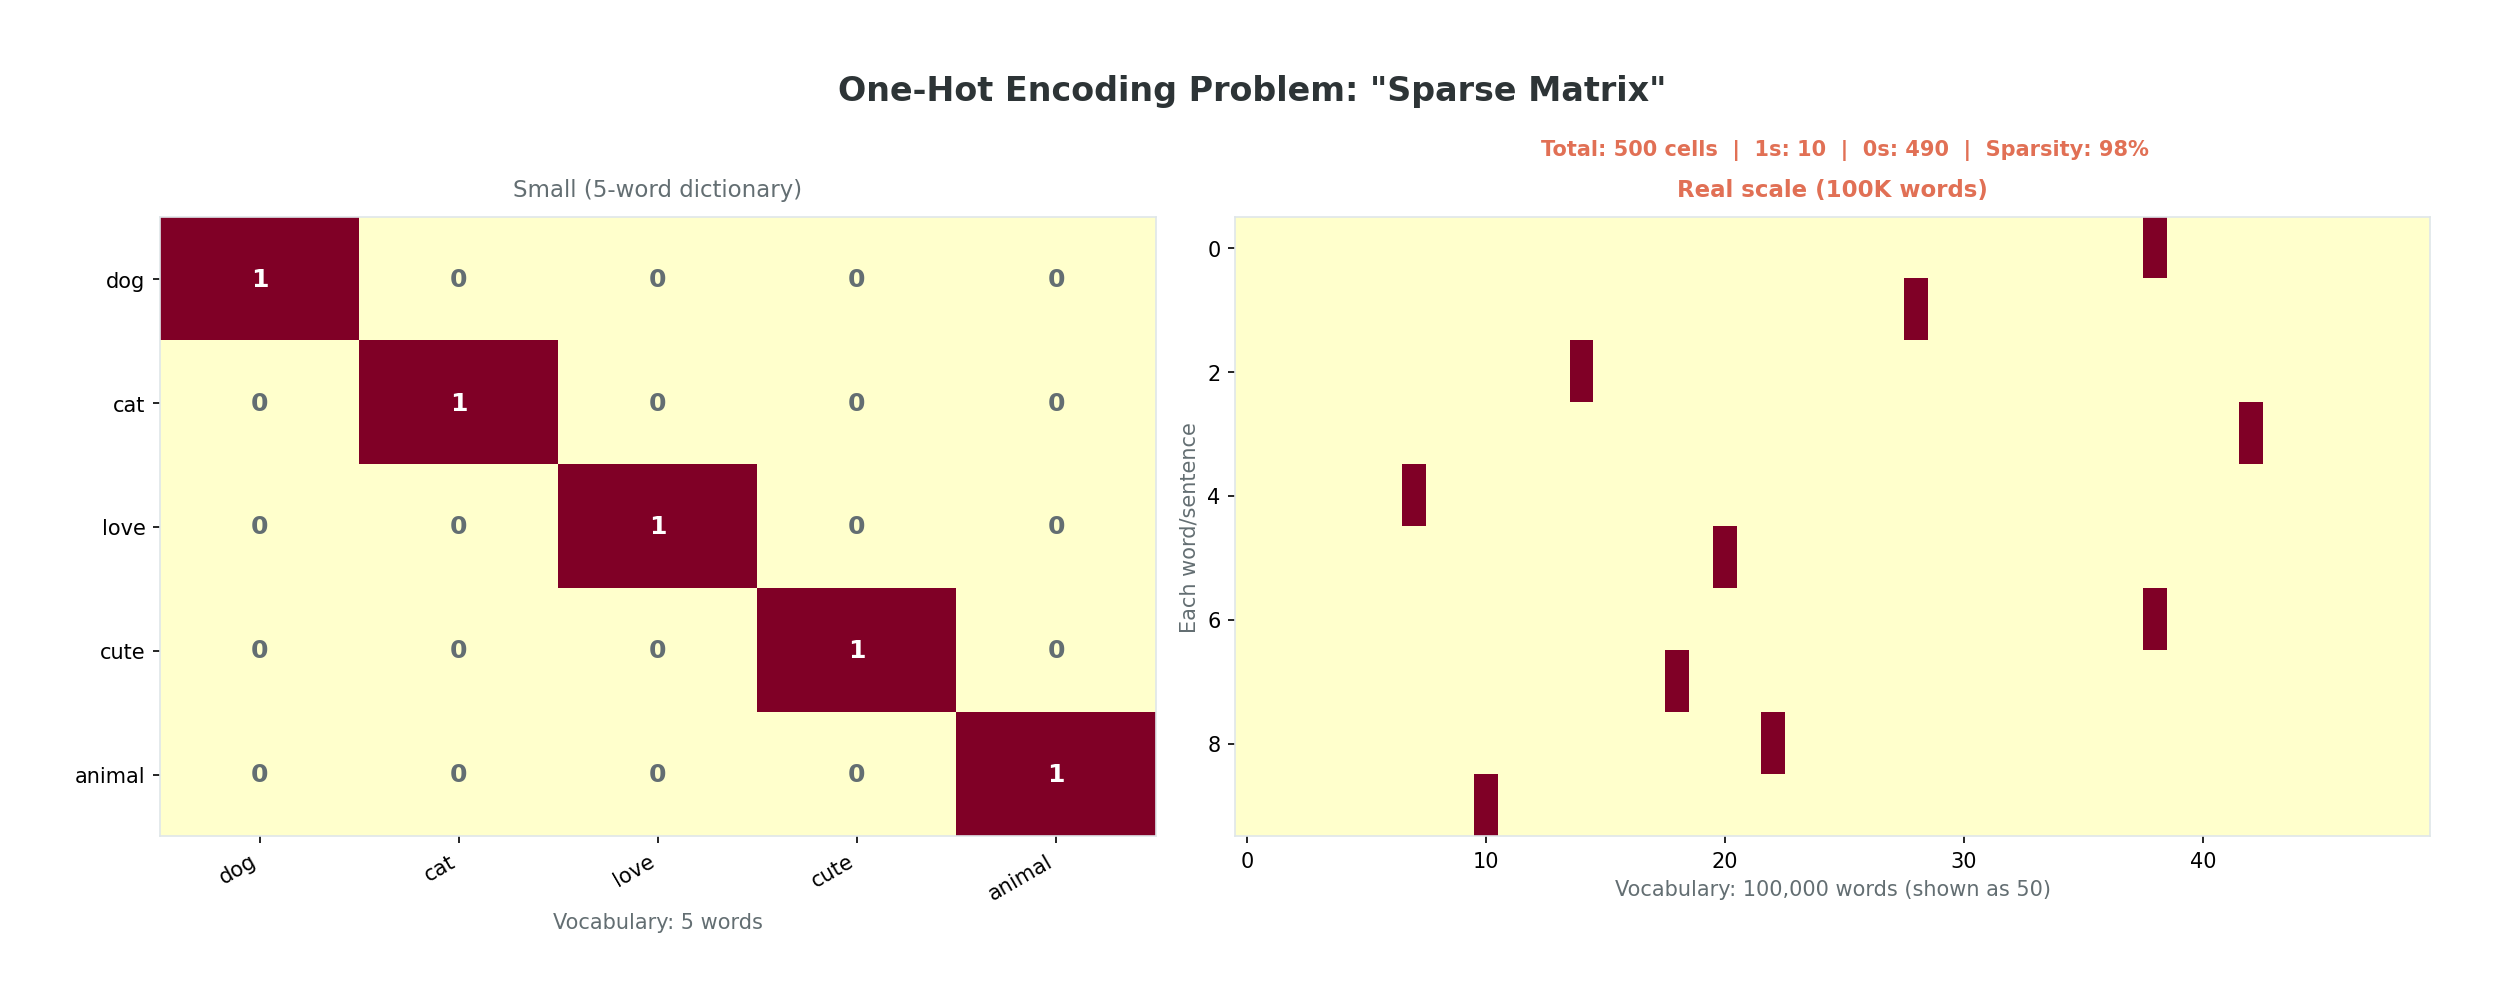

*▲ 원-핫 인코딩: 단어가 많아질수록 대부분이 0인 거대한 희소 행렬*

---

### 📊 TF-IDF (Term Frequency - Inverse Document Frequency)

원-핫 인코딩의 또 다른 발전형으로, 각 단어에 **"중요도 점수"**를 부여하는 방식입니다.

**핵심 아이디어: 자주 나오되, 흔하지 않은 단어 = 중요한 단어**

| 구성 요소 | 의미 | 예시 |
|-----------|------|------|
| **TF** (Term Frequency) | 해당 문서에서 얼마나 자주 등장하는가? | "AI"가 이 문서에서 5번 등장 → TF = 5 |
| **IDF** (Inverse Document Frequency) | 전체 문서 중 얼마나 드문가? | "AI"가 1000개 문서 중 10개에만 등장 → 높은 IDF |
| **TF × IDF** | 자주 등장 + 희귀 = 높은 점수 | "the"는 자주 나오지만 모든 문서에 있어서 점수 낮음 |

```
예시: "AI가 세상을 바꾸고 있습니다" 라는 문서에서:
  "AI"  →  TF 높음 × IDF 높음 = ★★★ 높은 점수 (핵심 키워드!)
  "는"  →  TF 높음 × IDF 낮음 = ☆☆☆ 낮은 점수 (흔한 조사)
```

> ⚠ **TF-IDF의 한계**: 여전히 **단어 순서와 의미**를 이해하지 못합니다.
> "강아지가 고양이를 쫓았다"와 "고양이가 강아지를 쫓았다"의 TF-IDF 벡터가 동일합니다!

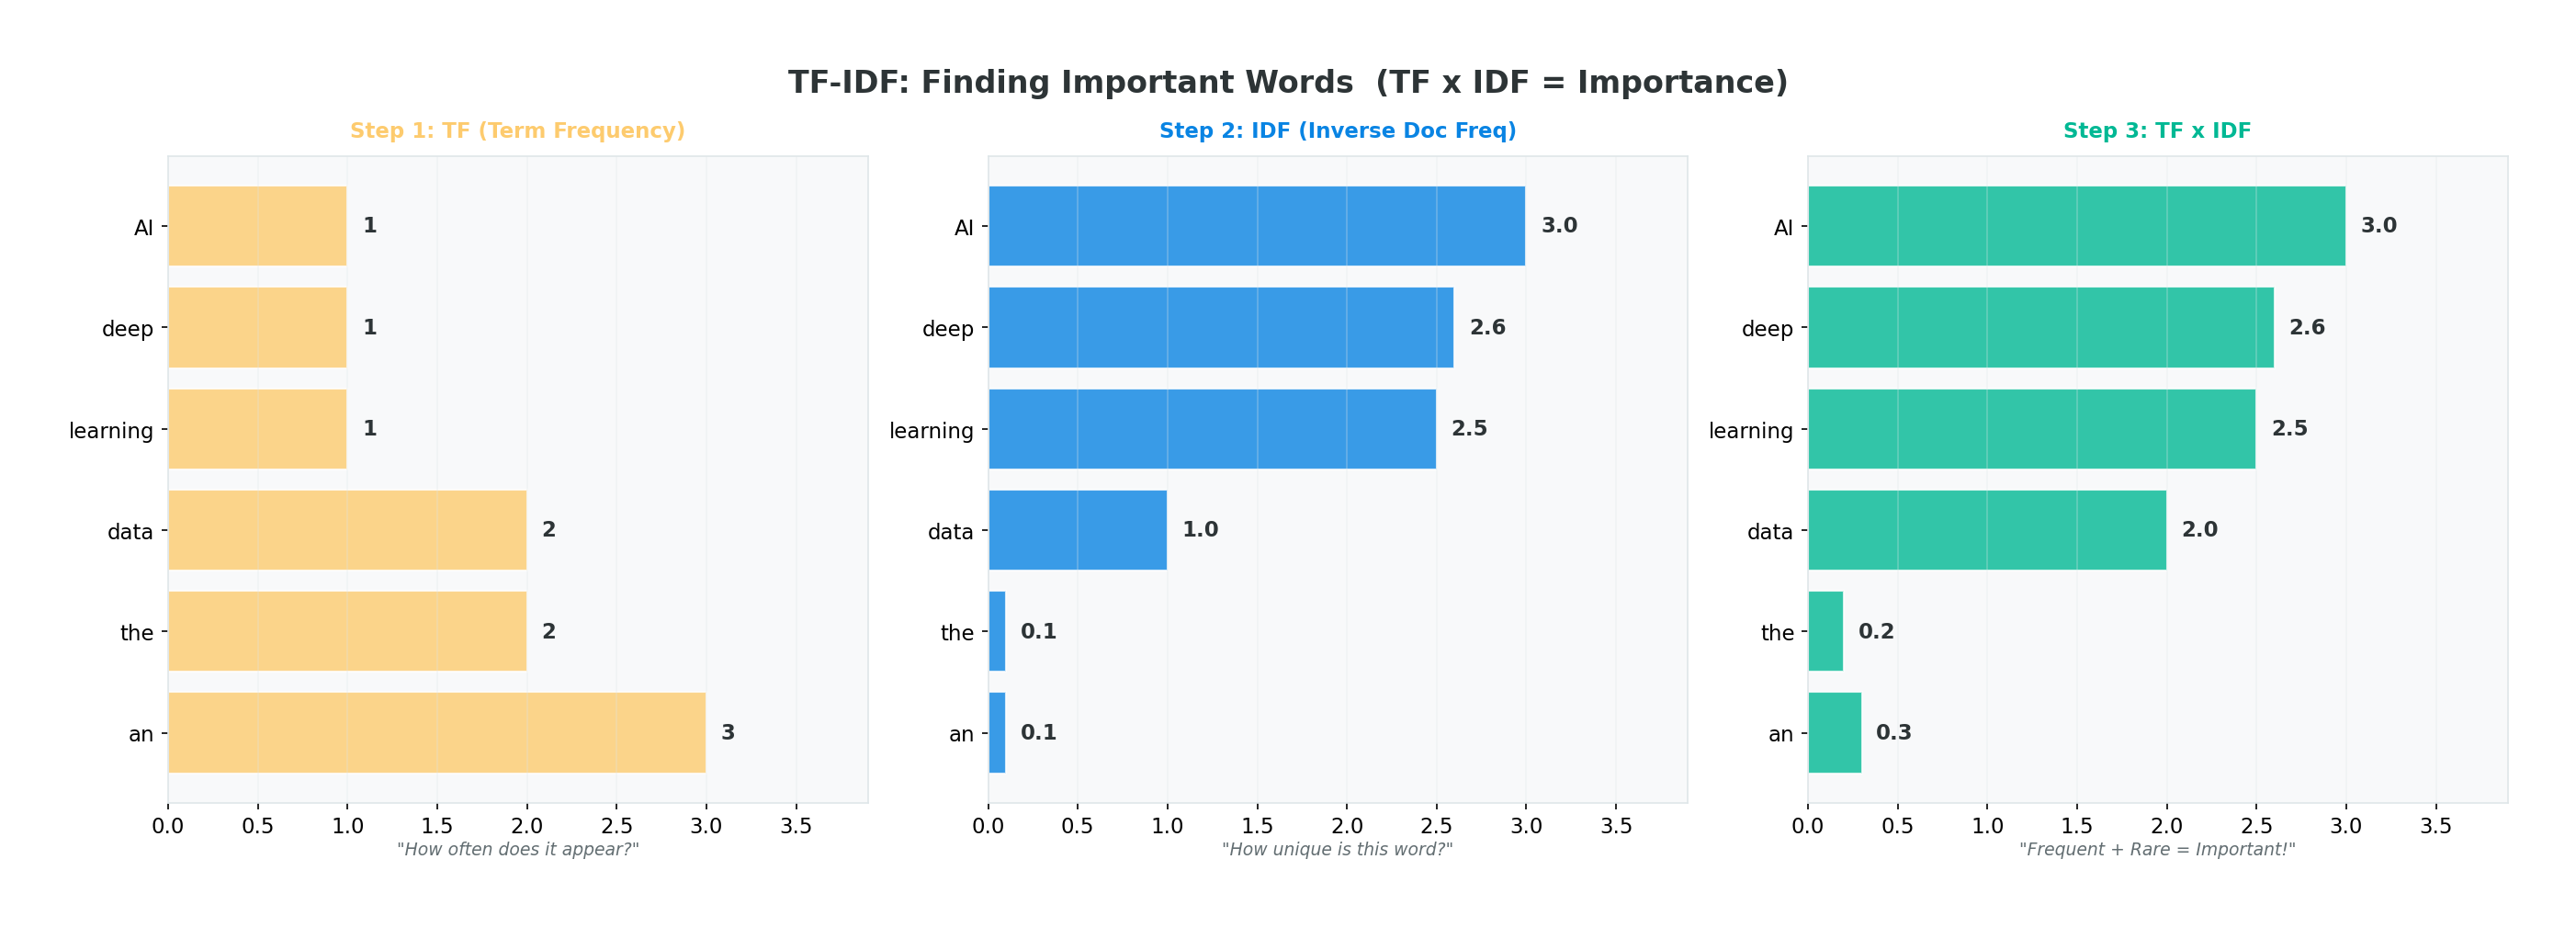

*▲ TF-IDF 3단계: 단어 빈도(TF) × 희귀도(IDF) = 중요도 점수. 흔한 조사(the, is)는 낮고, 핵심 키워드(AI, deep)가 높다*

In [4]:
# 원-핫 인코딩 직접 구현해보기
print("=== 원-핫 인코딩 예시 ===")

# 간단한 단어 사전 만들기
vocabulary = ["강아지", "고양이", "사랑", "귀엽다", "동물"]
print(f"단어 사전: {vocabulary}")
print(f"사전 크기: {len(vocabulary)}개 단어")
print()

def one_hot_encode(word, vocabulary):
    """단어를 원-핫 벡터로 변환"""
    vector = [0] * len(vocabulary)  # 0으로 채운 리스트
    if word in vocabulary:
        idx = vocabulary.index(word)
        vector[idx] = 1  # 해당 위치만 1로
    return vector

words_to_encode = ["강아지", "고양이", "사랑"]
for word in words_to_encode:
    vector = one_hot_encode(word, vocabulary)
    print(f"  '{word}' → {vector}")

print()
print("💡 '강아지'와 '고양이'의 관계를 숫자로 알 수 있을까요?")
v1 = np.array(one_hot_encode("강아지", vocabulary))
v2 = np.array(one_hot_encode("고양이", vocabulary))
v3 = np.array(one_hot_encode("사랑", vocabulary))

print(f"  '강아지' vs '고양이' 내적: {np.dot(v1, v2)} (0 = 관계 없음)")
print(f"  '강아지' vs '사랑'   내적: {np.dot(v1, v3)} (0 = 관계 없음)")
print("  ❌ 원-핫 인코딩으로는 단어 간 유사도를 파악할 수 없습니다!")

=== 원-핫 인코딩 예시 ===
단어 사전: ['강아지', '고양이', '사랑', '귀엽다', '동물']
사전 크기: 5개 단어

  '강아지' → [1, 0, 0, 0, 0]
  '고양이' → [0, 1, 0, 0, 0]
  '사랑' → [0, 0, 1, 0, 0]

💡 '강아지'와 '고양이'의 관계를 숫자로 알 수 있을까요?
  '강아지' vs '고양이' 내적: 0 (0 = 관계 없음)
  '강아지' vs '사랑'   내적: 0 (0 = 관계 없음)
  ❌ 원-핫 인코딩으로는 단어 간 유사도를 파악할 수 없습니다!


In [5]:
# TF-IDF 직접 체험해보기
from sklearn.feature_extraction.text import TfidfVectorizer

print('=== TF-IDF 실습 ===')
print()

# 3개의 간단한 문서
documents = [
    '강아지가 공원에서 뛰어놀고 있다',
    '고양이가 집에서 잠을 자고 있다',
    '강아지와 고양이가 함께 놀고 있다',
]

# TF-IDF 벡터화
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(documents)

# 결과 확인
feature_names = tfidf.get_feature_names_out()
print(f'단어 사전: {list(feature_names)}')
print(f'TF-IDF 행렬 크기: {tfidf_matrix.shape} (문서 수 x 단어 수)')
print()

import pandas as pd
df = pd.DataFrame(tfidf_matrix.toarray(), 
                  columns=feature_names,
                  index=[f'문서{i+1}' for i in range(len(documents))])
print('TF-IDF 점수 행렬:')
print(df.round(3).to_string())
print()

# 문서 유사도 계산
from sklearn.metrics.pairwise import cosine_similarity
sim = cosine_similarity(tfidf_matrix)
print('문서 간 유사도 (코사인 유사도):')
for i in range(len(documents)):
    for j in range(i+1, len(documents)):
        print(f'  문서{i+1} vs 문서{j+1}: {sim[i,j]:.3f}')
print()
print('💡 TF-IDF는 "단어 겹침"으로만 유사도를 측정합니다.')
print('   → "강아지"와 "개"가 같은 의미인지는 알 수 없습니다!')
print('   → 이 한계를 극복하는 것이 바로 "임베딩"입니다.')

=== TF-IDF 실습 ===

단어 사전: ['강아지가', '강아지와', '고양이가', '공원에서', '놀고', '뛰어놀고', '있다', '자고', '잠을', '집에서', '함께']
TF-IDF 행렬 크기: (3, 11) (문서 수 x 단어 수)

TF-IDF 점수 행렬:
      강아지가   강아지와   고양이가   공원에서     놀고   뛰어놀고     있다     자고     잠을    집에서     함께
문서1  0.546  0.000  0.000  0.546  0.000  0.546  0.323  0.000  0.000  0.000  0.000
문서2  0.000  0.000  0.384  0.000  0.000  0.000  0.298  0.505  0.505  0.505  0.000
문서3  0.000  0.505  0.384  0.000  0.505  0.000  0.298  0.000  0.000  0.000  0.505

문서 간 유사도 (코사인 유사도):
  문서1 vs 문서2: 0.096
  문서1 vs 문서3: 0.096
  문서2 vs 문서3: 0.236

💡 TF-IDF는 "단어 겹침"으로만 유사도를 측정합니다.
   → "강아지"와 "개"가 같은 의미인지는 알 수 없습니다!
   → 이 한계를 극복하는 것이 바로 "임베딩"입니다.


## 3️⃣ 임베딩 (Embedding) — "의미를 담은 공간에 배치하기"

임베딩은 **단어나 문장의 '의미'를 보존하면서 숫자 벡터로 표현**하는 방법입니다.

### 🗺 핵심 아이디어

> **비슷한 의미 = 비슷한 숫자**

- "강아지" 와 "개" → 숫자들이 서로 가깝게
- "왕" - "남자" + "여자" ≈ "여왕" (의미 연산이 가능!)

```
원-핫 인코딩:  "강아지" → [1, 0, 0, 0, ..., 0]   (10만 차원, 의미 없음)
임베딩:        "강아지" → [0.23, -0.45, 0.87, ...]  (300차원, 의미 보존!)
```

### 📈 임베딩의 발전 과정

| 시대 | 기술 | 특징 |
|------|------|------|
| 2013년 | **Word2Vec** | 단어 수준 임베딩 최초 |
| 2014년 | **GloVe** | 전체 문서 통계 활용 |
| 2018년 | **BERT** | 문맥 고려 임베딩 |
| 2022년~ | **LLM 임베딩** | GPT, Llama 기반 고성능 |

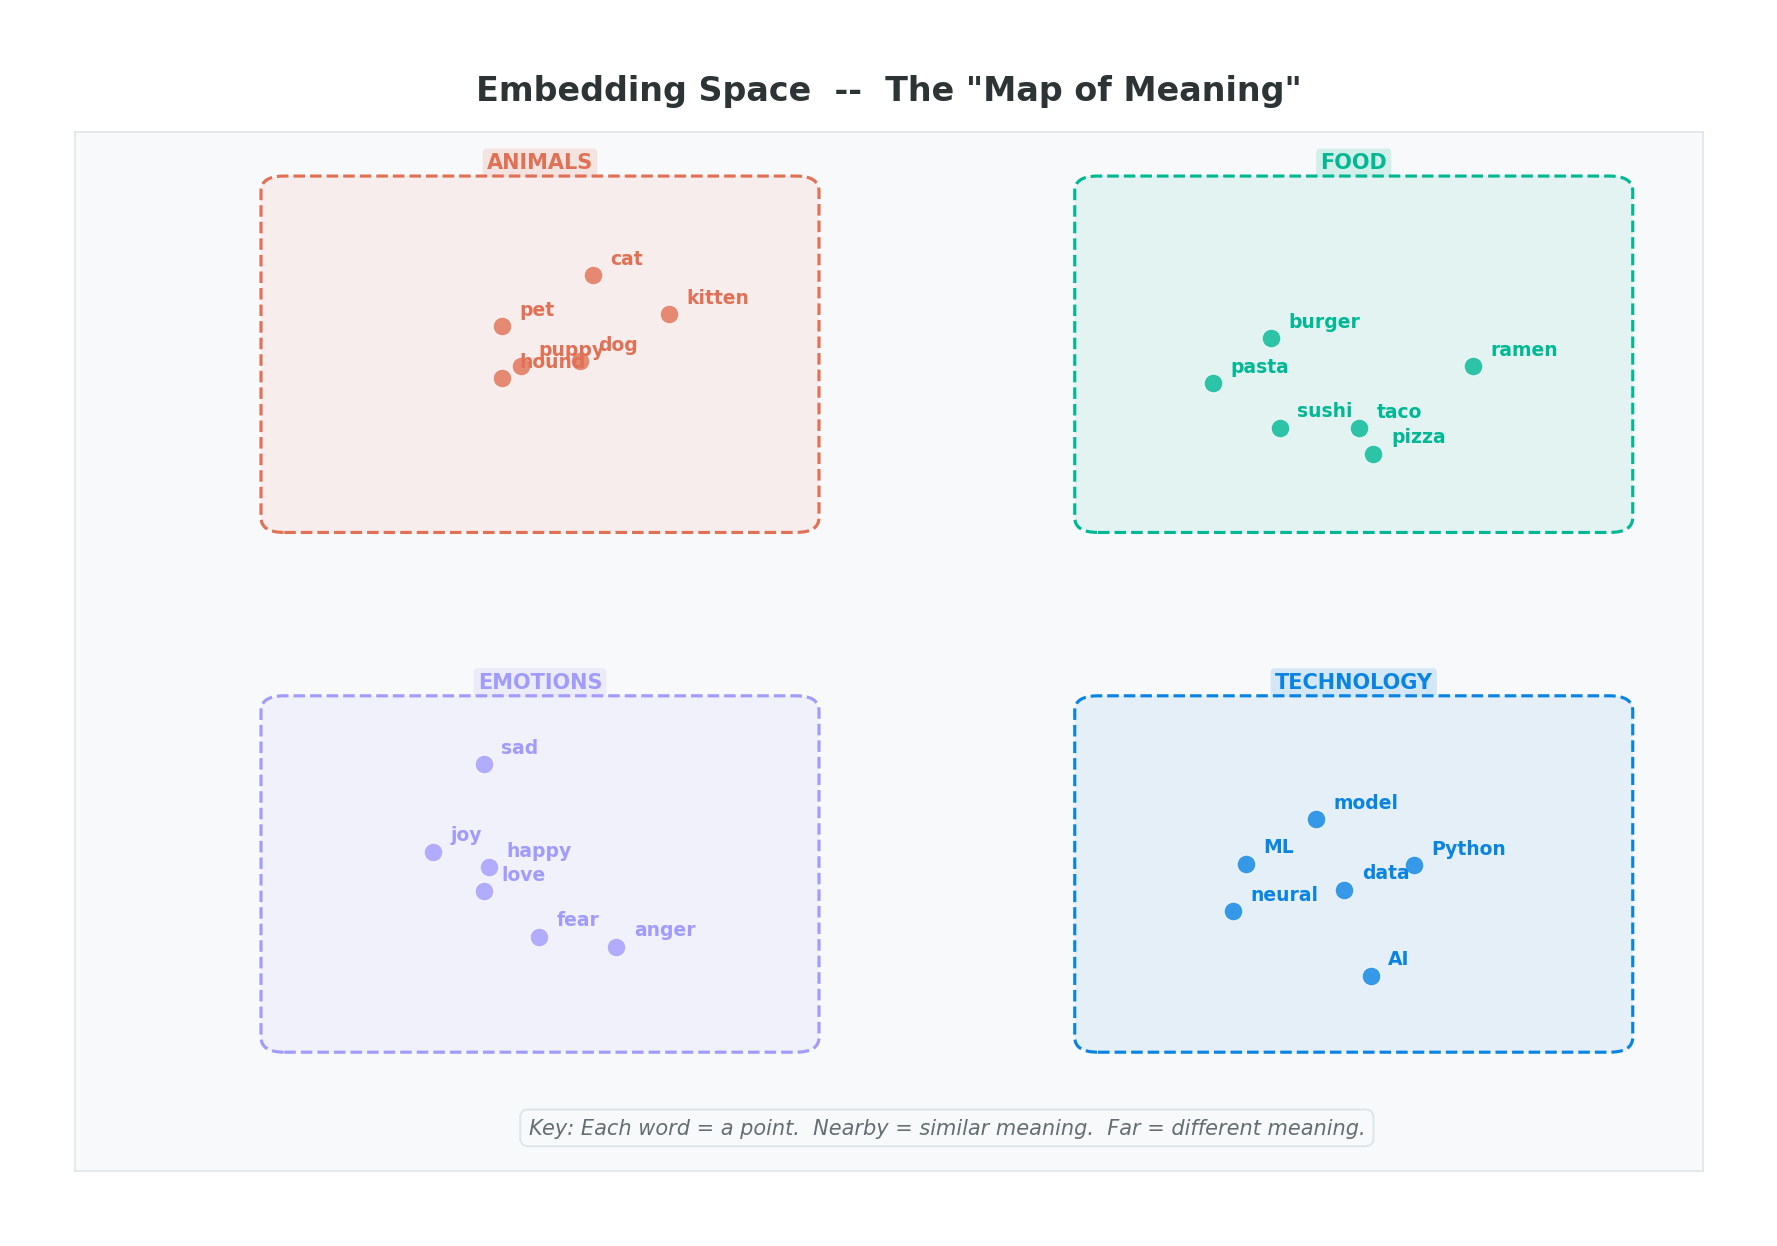

*▲ 임베딩 공간의 "단어 지도" — 비슷한 의미의 단어들이 자연스럽게 이웃에 모인다*

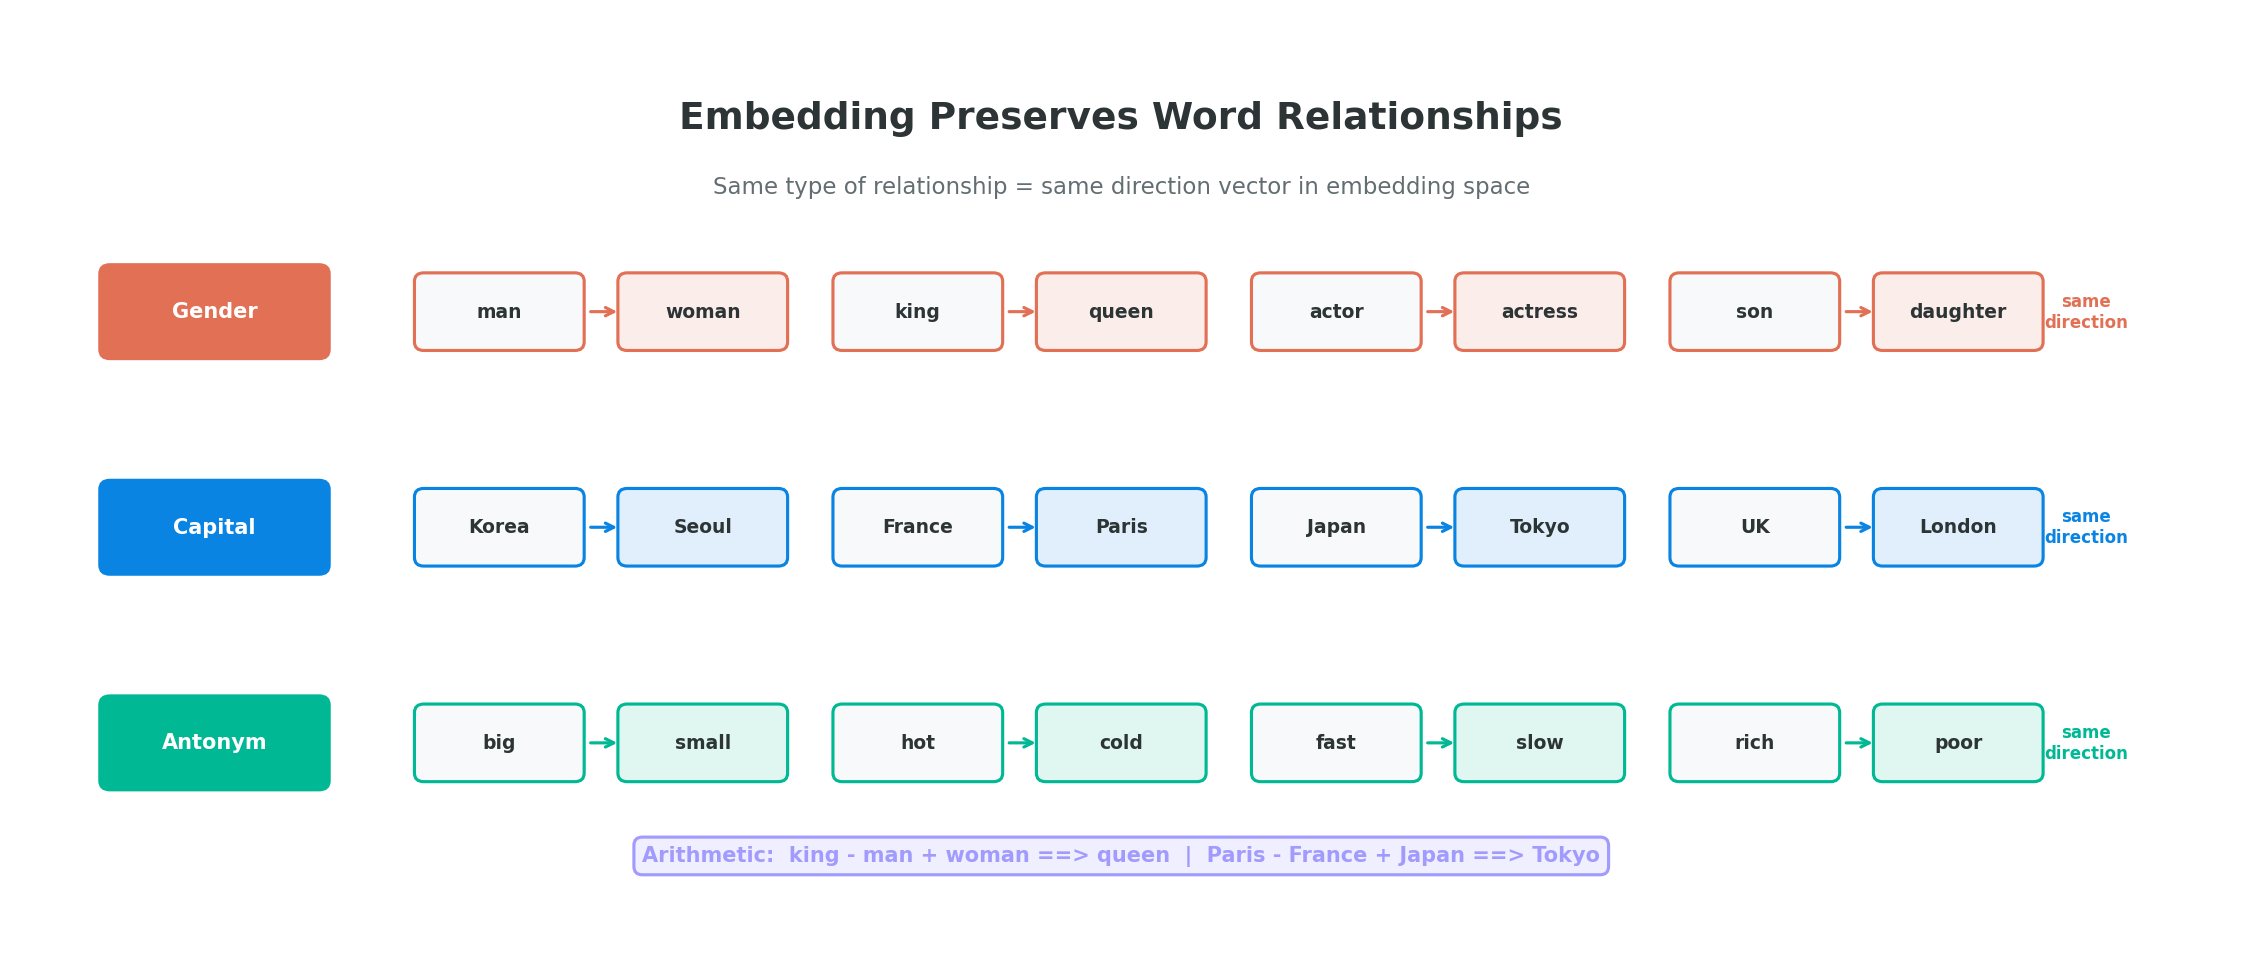

*▲ 관계가 보존된다 — 같은 종류의 관계는 항상 같은 방향의 벡터로 표현된다*


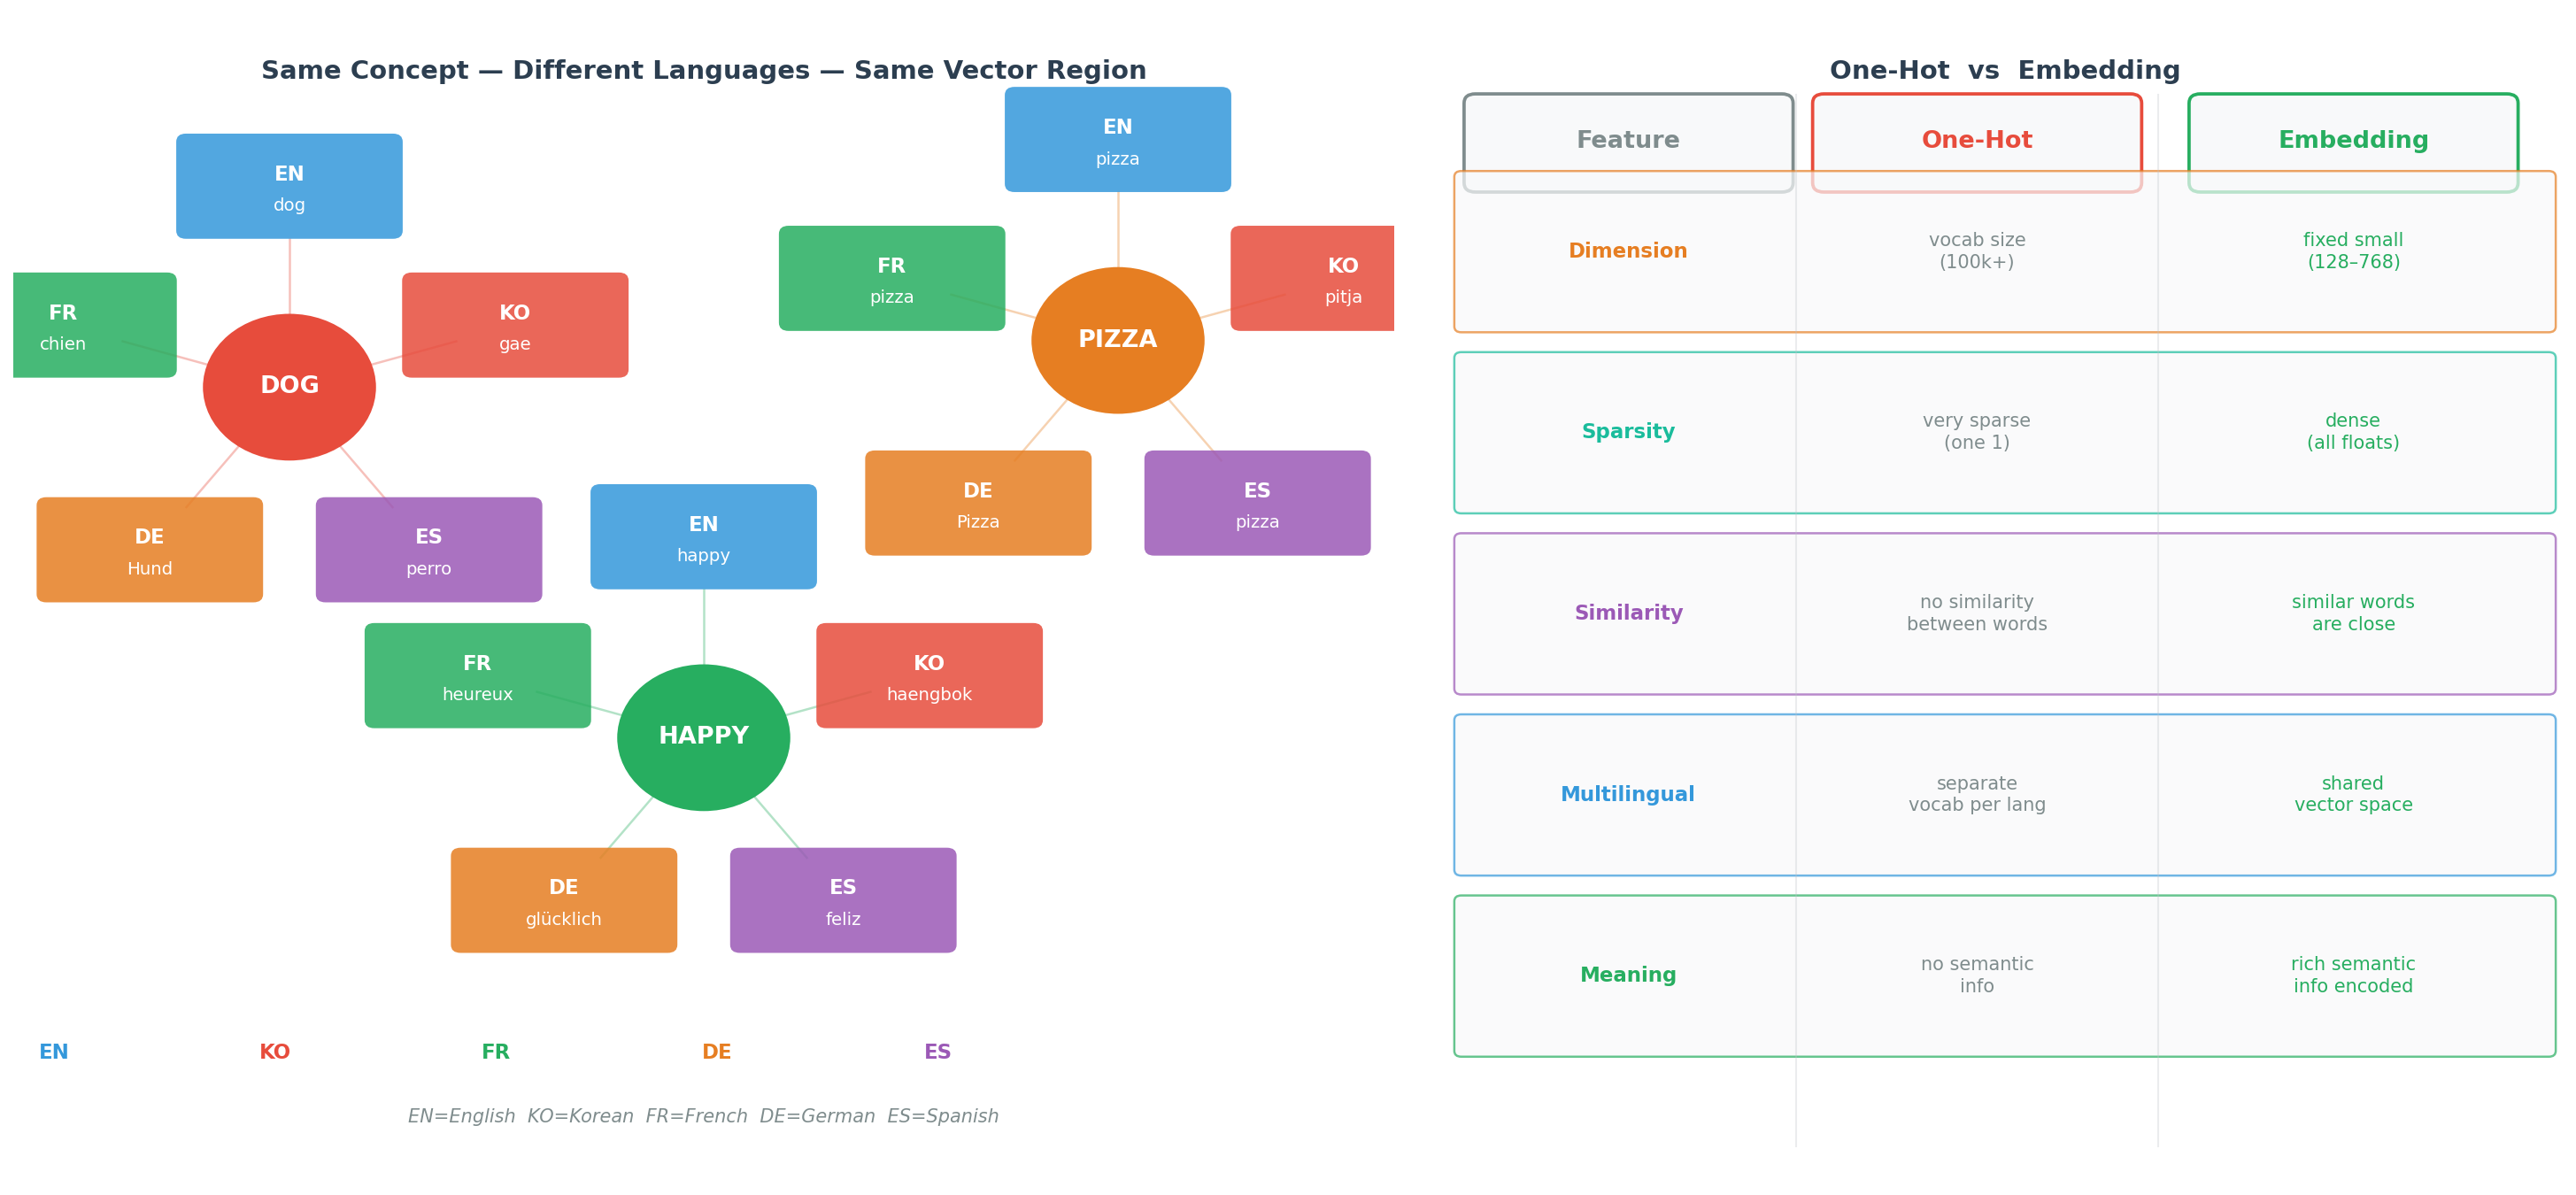

*▲ 언어를 넘어선 이해 — 같은 의미의 단어들은 언어가 달라도 같은 위치에 모인다*


=== 임베딩 개념 시각화 (2차원 예시) ===
실제 임베딩은 수백~수천 차원이지만, 이해를 위해 2차원으로 표현합니다.



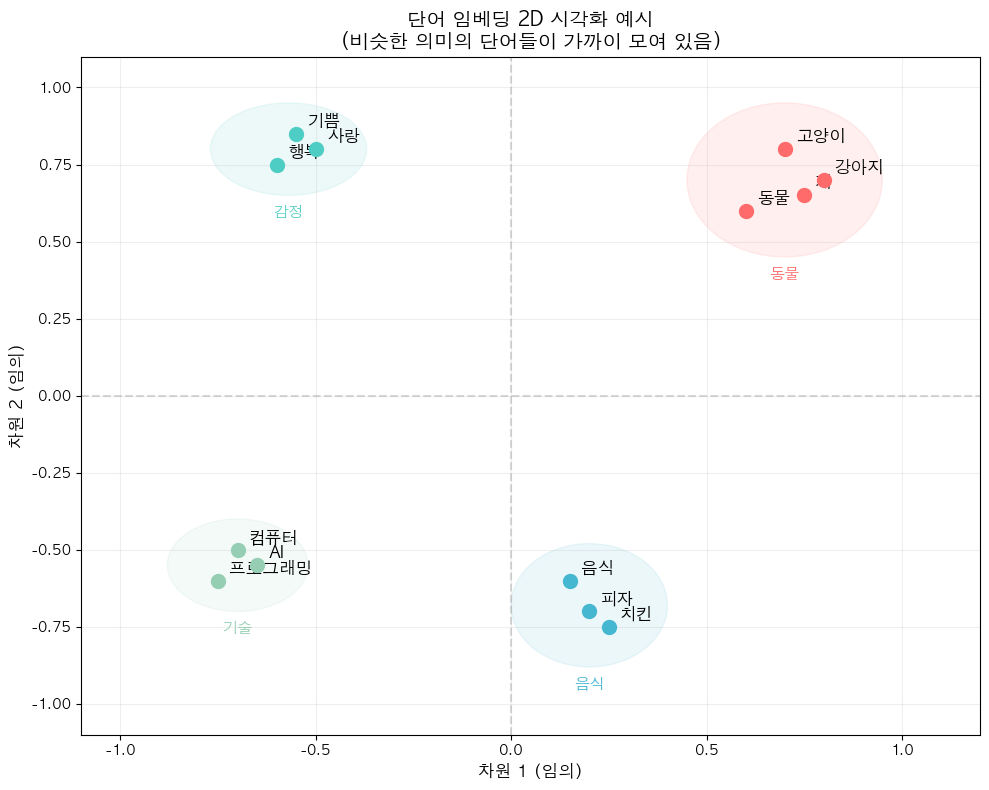


💡 핵심: 비슷한 의미의 단어들이 공간에서 가까이 모여 있습니다!


In [6]:
# 임베딩의 개념을 2D로 시각화해보기 (가상의 예시)
print("=== 임베딩 개념 시각화 (2차원 예시) ===")
print("실제 임베딩은 수백~수천 차원이지만, 이해를 위해 2차원으로 표현합니다.")
print()

# 가상의 2D 임베딩 좌표 (의미상 유사한 것들이 가깝게 배치)
word_embeddings_2d = {
    # 동물 관련
    "강아지": [0.8, 0.7],
    "개": [0.75, 0.65],
    "고양이": [0.7, 0.8],
    "동물": [0.6, 0.6],
    
    # 감정 관련
    "사랑": [-0.5, 0.8],
    "행복": [-0.6, 0.75],
    "기쁨": [-0.55, 0.85],
    
    # 음식 관련
    "피자": [0.2, -0.7],
    "치킨": [0.25, -0.75],
    "음식": [0.15, -0.6],
    
    # 기술 관련
    "컴퓨터": [-0.7, -0.5],
    "AI": [-0.65, -0.55],
    "프로그래밍": [-0.75, -0.6],
}

# 색상 구분
colors = {
    "강아지": "#FF6B6B", "개": "#FF6B6B", "고양이": "#FF6B6B", "동물": "#FF6B6B",
    "사랑": "#4ECDC4", "행복": "#4ECDC4", "기쁨": "#4ECDC4",
    "피자": "#45B7D1", "치킨": "#45B7D1", "음식": "#45B7D1",
    "컴퓨터": "#96CEB4", "AI": "#96CEB4", "프로그래밍": "#96CEB4",
}

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

for word, (x, y) in word_embeddings_2d.items():
    ax.scatter(x, y, s=100, color=colors[word], zorder=5)
    ax.annotate(word, (x, y), textcoords="offset points", xytext=(8, 5),
               fontsize=12, fontweight='bold')

# 그룹 영역 표시
from matplotlib.patches import Ellipse
groups = [
    (0.7, 0.7, 0.25, 0.25, '#FF6B6B', '동물'),
    (-0.57, 0.8, 0.2, 0.15, '#4ECDC4', '감정'),
    (0.2, -0.68, 0.2, 0.2, '#45B7D1', '음식'),
    (-0.7, -0.55, 0.18, 0.15, '#96CEB4', '기술'),
]

for cx, cy, w, h, color, label in groups:
    ellipse = Ellipse((cx, cy), w*2, h*2, alpha=0.1, color=color)
    ax.add_patch(ellipse)
    ax.text(cx, cy - h - 0.07, label, ha='center', fontsize=11,
           color=color, fontweight='bold')

ax.set_xlim(-1.1, 1.2)
ax.set_ylim(-1.1, 1.1)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.3)
ax.set_xlabel('차원 1 (임의)', fontsize=12)
ax.set_ylabel('차원 2 (임의)', fontsize=12)
ax.set_title('단어 임베딩 2D 시각화 예시\n(비슷한 의미의 단어들이 가까이 모여 있음)', 
            fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('embedding_concept.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n💡 핵심: 비슷한 의미의 단어들이 공간에서 가까이 모여 있습니다!")

---
# Part 2. 수학 기초 — 벡터와 유사도

## 📐 벡터(Vector)란?

벡터는 **여러 숫자들의 순서 있는 목록**입니다.  
일상에서도 이미 벡터를 사용하고 있습니다!

| 예시 | 벡터 표현 | 설명 |
|------|-----------|------|
| 지도 위 위치 | `[37.5665, 126.9780]` | 위도, 경도 2개 숫자 |
| RGB 색상 | `[255, 128, 0]` | 빨강, 초록, 파랑 3개 숫자 |
| 학생 성적 | `[95, 82, 78, 90]` | 국어, 영어, 수학, 과학 |
| 단어 임베딩 | `[0.23, -0.45, 0.87, ...]` | 수백~수천 개 숫자 |

> 임베딩은 각 단어/문장을 N차원 공간의 **한 점(좌표)**으로 표현합니다.

## 📏 유사도(Similarity) — 두 벡터가 얼마나 비슷한가?

임베딩에서 가장 많이 쓰는 유사도 측정: **코사인 유사도**

두 벡터가 **같은 방향을 가리키면 유사**, **반대 방향이면 다름**으로 판단합니다.

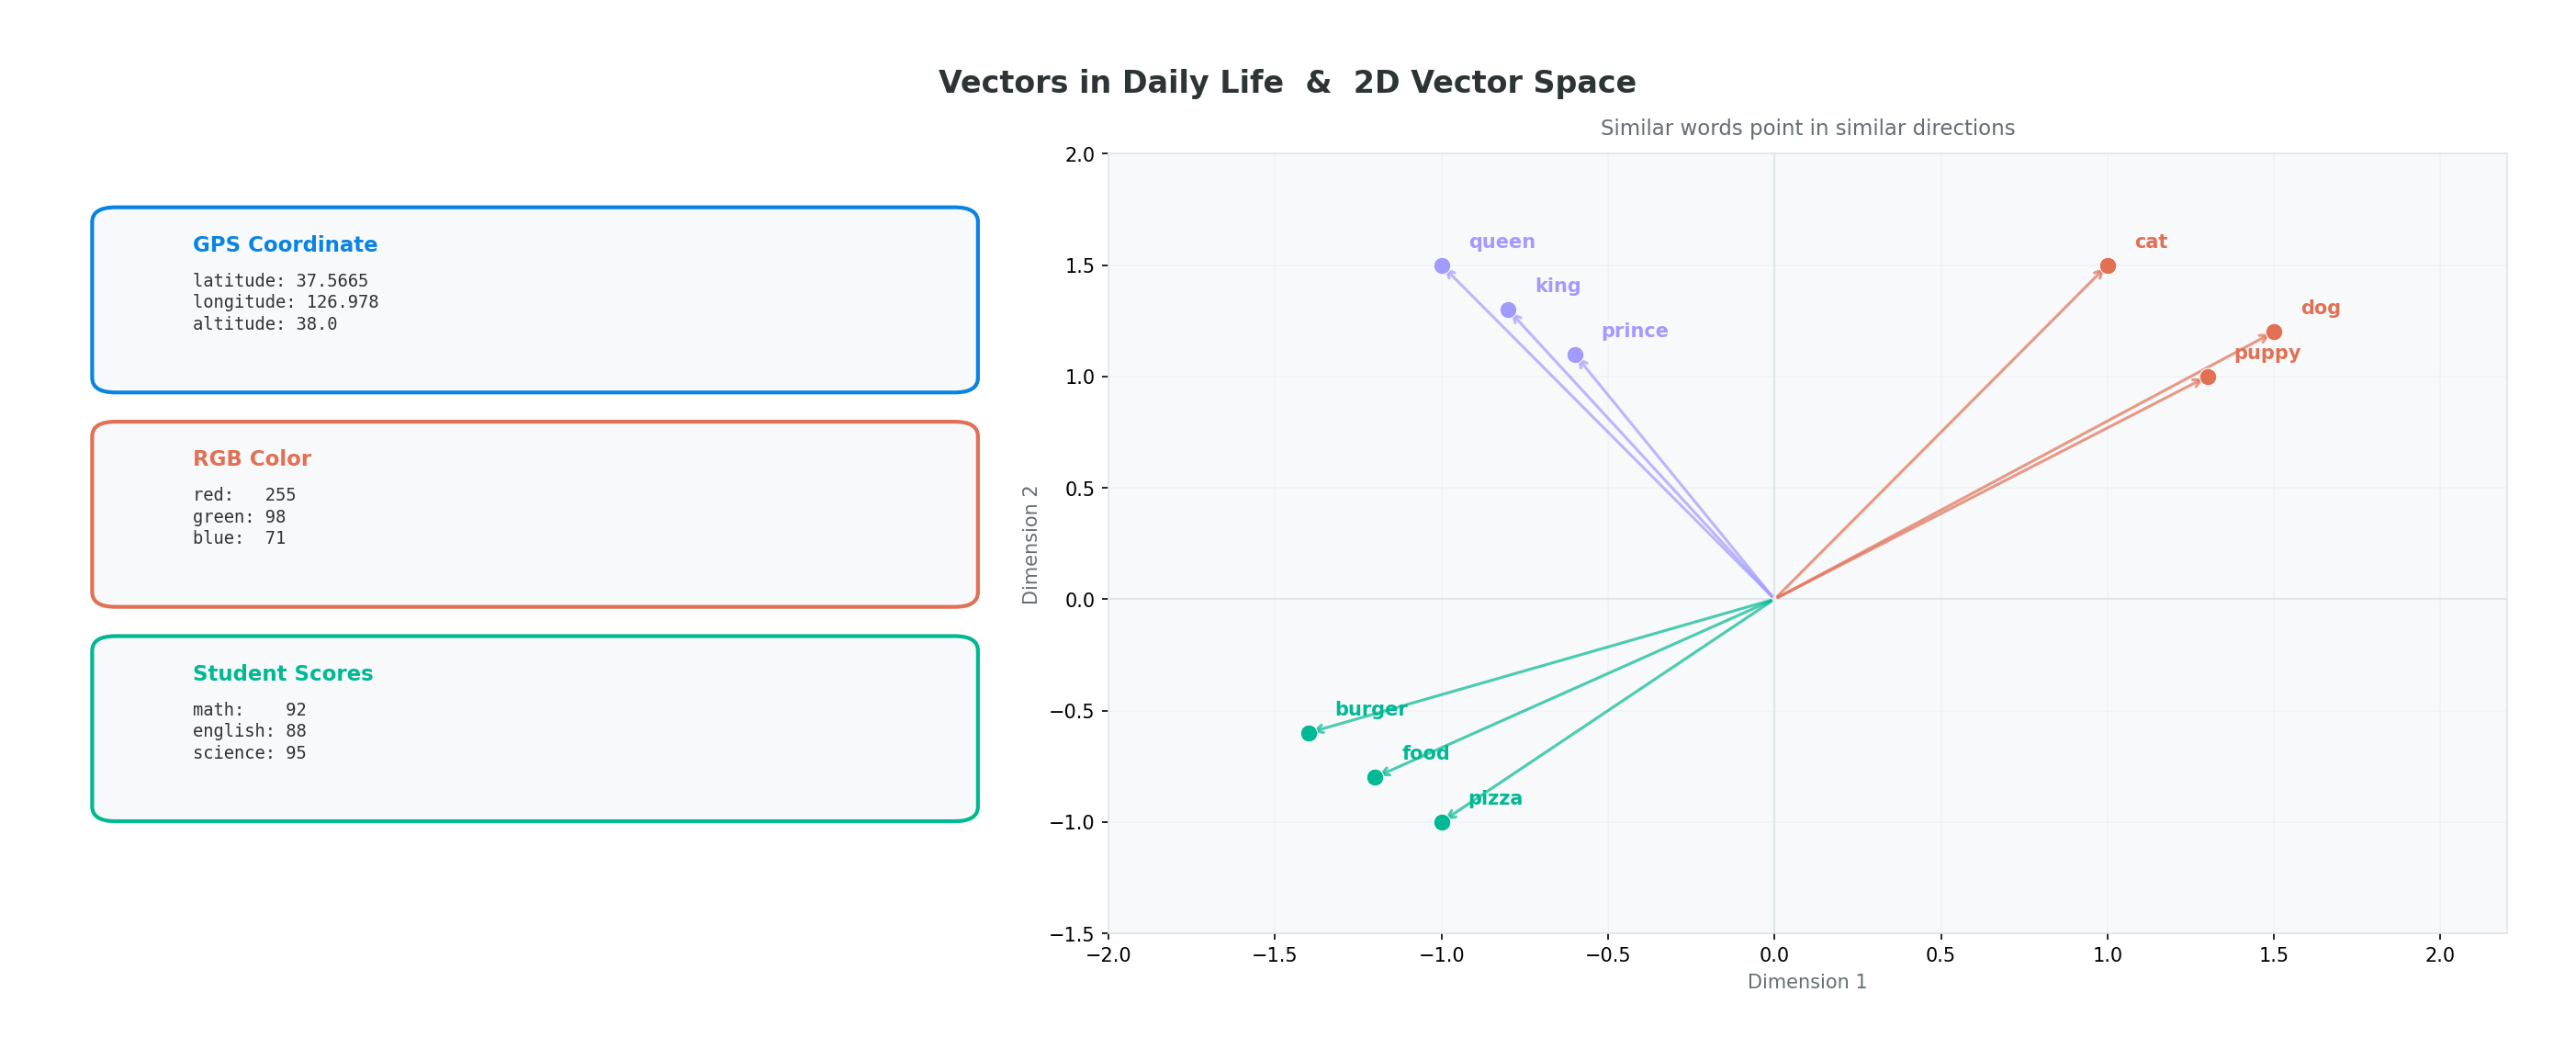

*▲ 벡터 직관: 숫자 목록으로 공간의 위치를 표현 — 가까운 점 = 비슷한 의미*

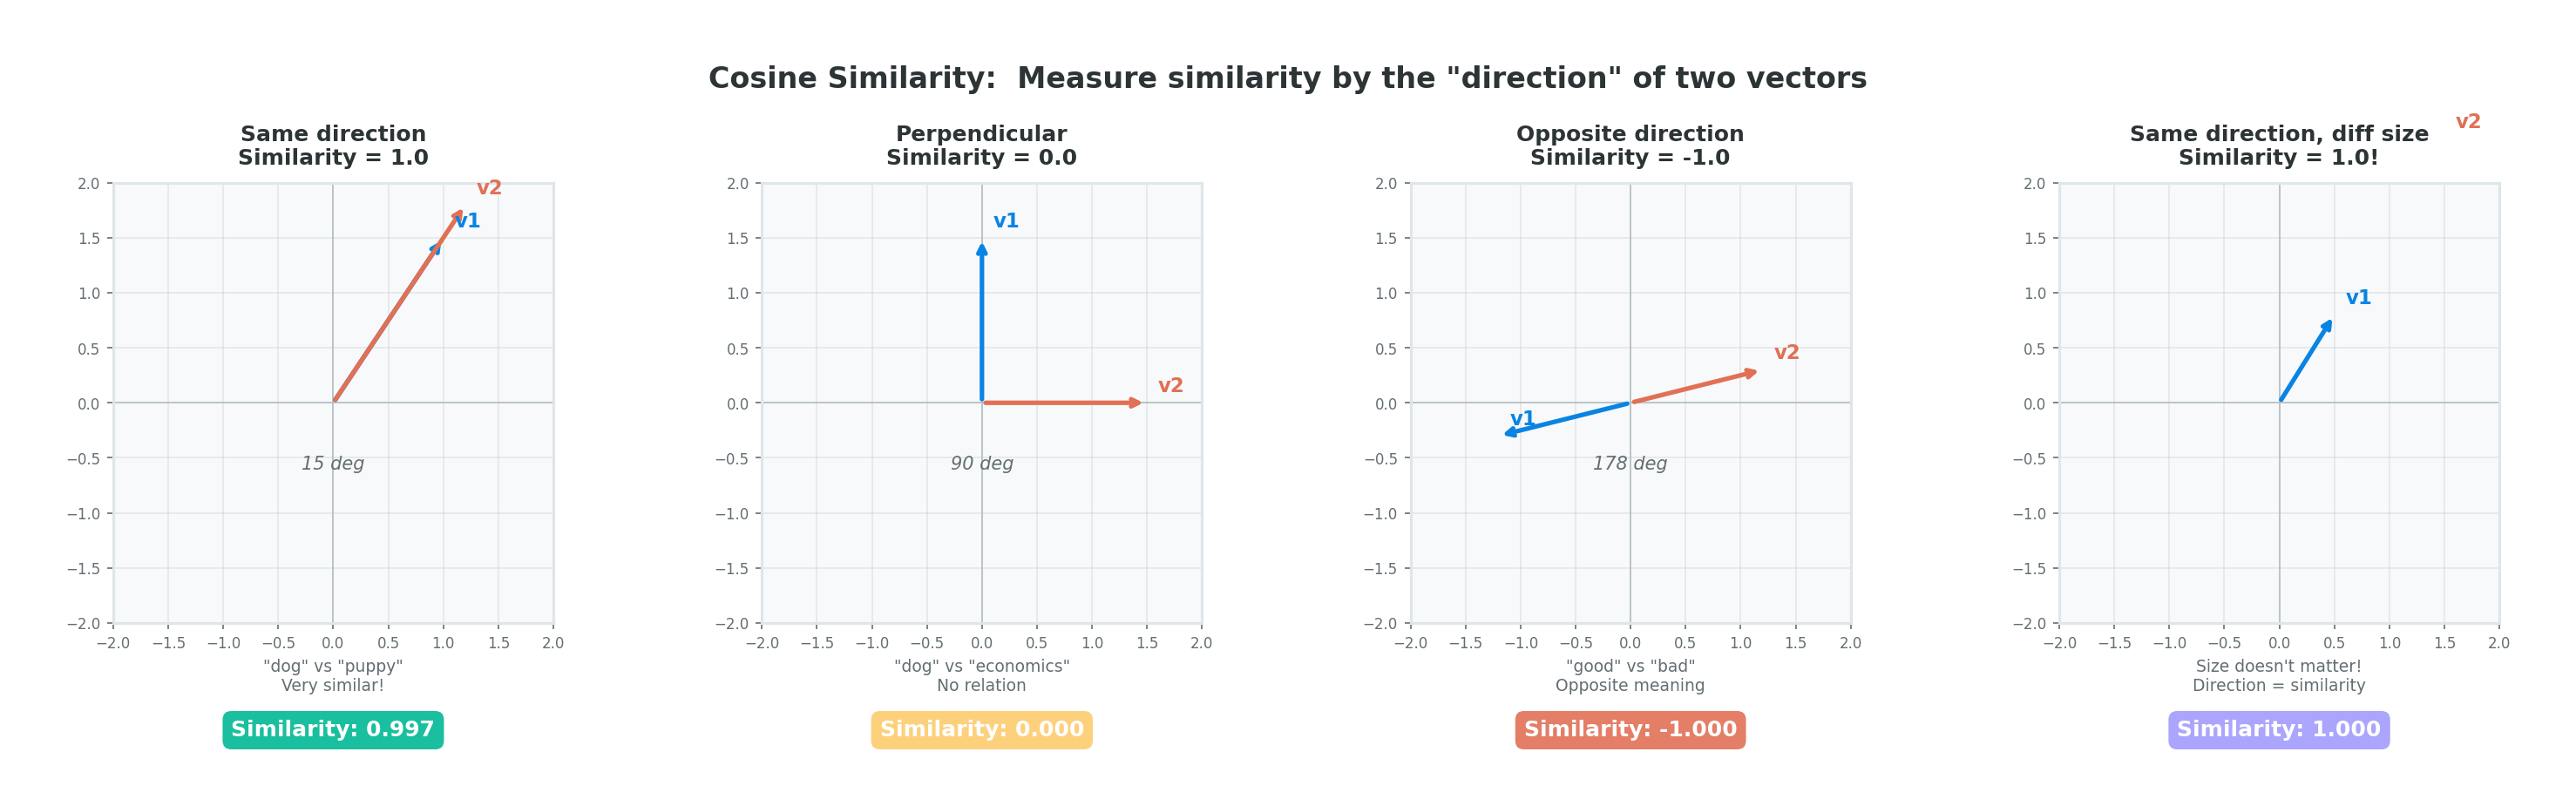

*▲ 코사인 유사도: 벡터의 크기가 아닌 방향으로 유사도 측정 (-1 ~ +1)*

In [7]:
# 코사인 유사도 시각적으로 이해하기
print("=== 코사인 유사도 이해하기 ===")
print()

def cosine_sim(v1, v2):
    """두 벡터의 코사인 유사도 계산"""
    v1, v2 = np.array(v1), np.array(v2)
    dot_product = np.dot(v1, v2)           # 내적
    norm_v1 = np.linalg.norm(v1)           # v1의 크기
    norm_v2 = np.linalg.norm(v2)           # v2의 크기
    return dot_product / (norm_v1 * norm_v2)

# 예시 벡터들 (2차원)
vectors = {
    "벡터 A (강아지)": [1.0, 0.8],
    "벡터 B (개)": [-0.2, 0.55],
    "벡터 C (컴퓨터)": [-0.7, -0.5],
    "벡터 D (같은 방향 큰 벡터)": [2.0, 1.6],
}

base = vectors["벡터 A (강아지)"]
print(f"기준 벡터: 벡터 A = {base}")
print()
for name, vec in list(vectors.items())[1:]:
    sim = cosine_sim(base, vec)
    bar = "█" * int(abs(sim) * 20)
    print(f"  A vs {name}:")
    print(f"    코사인 유사도 = {sim:.4f}  [{bar}]")
    print()

print("💡 '벡터 D'는 크기가 두 배지만, 방향이 같아서 유사도가 거의 1!")
print("   → 코사인 유사도는 '방향'만 보기 때문입니다.")

=== 코사인 유사도 이해하기 ===

기준 벡터: 벡터 A = [1.0, 0.8]

  A vs 벡터 B (개):
    코사인 유사도 = 0.3202  [██████]

  A vs 벡터 C (컴퓨터):
    코사인 유사도 = -0.9985  [███████████████████]

  A vs 벡터 D (같은 방향 큰 벡터):
    코사인 유사도 = 1.0000  [████████████████████]

💡 '벡터 D'는 크기가 두 배지만, 방향이 같아서 유사도가 거의 1!
   → 코사인 유사도는 '방향'만 보기 때문입니다.


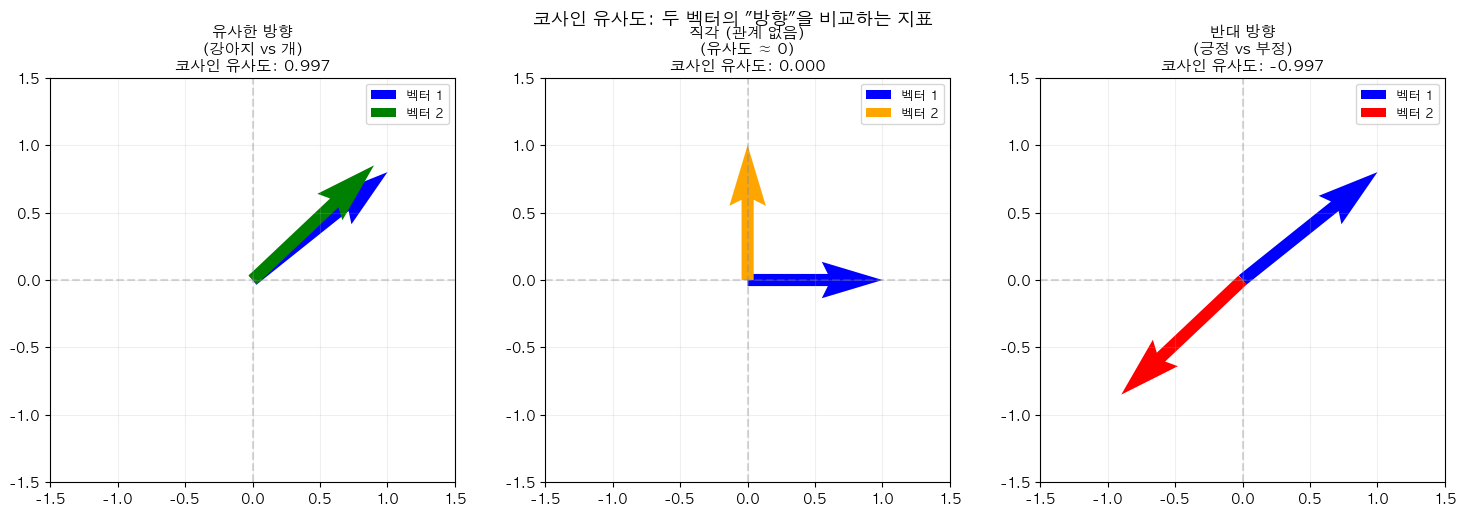

In [8]:
# 코사인 유사도 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

cases = [
    ([1, 0.8], [0.9, 0.85], "유사한 방향\n(강아지 vs 개)", "green"),
    ([1, 0], [0, 1], "직각 (관계 없음)\n(유사도 ≈ 0)", "orange"),
    ([1, 0.8], [-0.9, -0.85], "반대 방향\n(긍정 vs 부정)", "red"),
]

for ax, (v1, v2, title, color) in zip(axes, cases):
    v1, v2 = np.array(v1), np.array(v2)
    sim = cosine_sim(v1, v2)
    
    ax.quiver(0, 0, v1[0], v1[1], angles='xy', scale_units='xy', scale=1,
             color='blue', label='벡터 1', width=0.03)
    ax.quiver(0, 0, v2[0], v2[1], angles='xy', scale_units='xy', scale=1,
             color=color, label='벡터 2', width=0.03)
    
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
    ax.axvline(x=0, color='gray', linestyle='--', alpha=0.3)
    ax.set_title(f"{title}\n코사인 유사도: {sim:.3f}", fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.2)
    ax.set_aspect('equal')

plt.suptitle('코사인 유사도: 두 벡터의 "방향"을 비교하는 지표', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cosine_similarity.png', dpi=150, bbox_inches='tight')
plt.show()

---
# Part 3. 실습 — sentence-transformers (로컬/Colab)

## 🤗 sentence-transformers란?

- Hugging Face에서 제공하는 **오픈소스 임베딩 라이브러리**
- **무료**로 사용 가능, API 키 불필요!
- Google Colab에서 바로 실행 가능
- 다국어 지원 (한국어 포함!)

### 주요 모델
| 모델 | 특징 | 추천 용도 |
|------|------|----------|
| `all-MiniLM-L6-v2` | 빠름, 영어 특화 | 빠른 프로토타입 |
| `paraphrase-multilingual-MiniLM-L12-v2` | 다국어 지원 | 한국어 포함 |
| `jhgan/ko-sroberta-multitask` | 한국어 특화 | 한국어 전용 |

In [9]:
import warnings, logging
warnings.filterwarnings('ignore')
logging.getLogger('sentence_transformers').setLevel(logging.ERROR)
logging.getLogger('transformers').setLevel(logging.ERROR)

from sentence_transformers import SentenceTransformer
import numpy as np

print('모델 로딩 중... (처음 실행 시 다운로드가 필요합니다)')

# 다국어 지원 모델 로드 (한국어 포함)
model_local = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

warnings.filterwarnings('default')
print(f'모델 로드 완료!')
print(f'   모델명: paraphrase-multilingual-MiniLM-L12-v2')
print(f'   임베딩 차원: {model_local.get_sentence_embedding_dimension()}')


모델 로딩 중... (처음 실행 시 다운로드가 필요합니다)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


모델 로드 완료!
   모델명: paraphrase-multilingual-MiniLM-L12-v2
   임베딩 차원: 384


In [10]:
# 문장을 임베딩 벡터로 변환해보기
print("=== 문장 임베딩 체험 ===")
print()

sample_sentences = [
    "강아지가 공원에서 뛰어놀고 있다.",
    "개가 잔디밭에서 달리고 있어요.",
    "오늘 날씨가 정말 맑고 화창하다.",
    "I love dogs playing in the park.",  # 영어도 됩니다!
]

# 임베딩 생성
embeddings = model_local.encode(sample_sentences)

print("생성된 임베딩 정보:")
print(f"  문장 수: {len(sample_sentences)}개")
print(f"  각 임베딩 차원: {embeddings.shape[1]}")
print(f"  전체 shape: {embeddings.shape} (문장 수 x 차원)")
print()

# 첫 번째 문장의 임베딩 일부 출력
print(f"첫 번째 문장: '{sample_sentences[0]}'")
print(f"임베딩 벡터 (앞 10개 값만): {embeddings[0][:10].round(4)}")
print("...")
print(f"(총 {embeddings.shape[1]}개의 숫자로 문장의 의미를 표현)")

=== 문장 임베딩 체험 ===

생성된 임베딩 정보:
  문장 수: 4개
  각 임베딩 차원: 384
  전체 shape: (4, 384) (문장 수 x 차원)

첫 번째 문장: '강아지가 공원에서 뛰어놀고 있다.'
임베딩 벡터 (앞 10개 값만): [ 0.3211 -0.035  -0.4344  0.036   0.031   0.0094  0.0257 -0.1248  0.1653
 -0.2157]
...
(총 384개의 숫자로 문장의 의미를 표현)


In [11]:
# 문장 간 유사도 계산
print("=== 문장 간 유사도 계산 ===")
print()

from sklearn.metrics.pairwise import cosine_similarity

# 유사도 행렬 계산
sim_matrix = cosine_similarity(embeddings)

print("📊 유사도 행렬 (코사인 유사도):")
print()
# 헤더
labels = [f"S{i+1}" for i in range(len(sample_sentences))]
print(f"{'':>4}", end="")
for l in labels:
    print(f"{l:>8}", end="")
print()

for i, (label, row) in enumerate(zip(labels, sim_matrix)):
    print(f"{label:>4}", end="")
    for val in row:
        print(f"{val:>8.3f}", end="")
    print()

print()
print("문장 목록:")
for i, s in enumerate(sample_sentences):
    print(f"  S{i+1}: {s}")

print()
print("🔍 분석:")
print(f"  S1 vs S2 (강아지/개 — 비슷한 의미): {sim_matrix[0,1]:.3f} ← 높은 유사도!")
print(f"  S1 vs S3 (강아지/날씨 — 다른 의미): {sim_matrix[0,2]:.3f} ← 낮은 유사도")
print(f"  S1 vs S4 (한국어/영어 — 같은 의미): {sim_matrix[0,3]:.3f} ← 다국어 이해!")

=== 문장 간 유사도 계산 ===

📊 유사도 행렬 (코사인 유사도):

          S1      S2      S3      S4
  S1   1.000   0.713   0.082   0.651
  S2   0.713   1.000   0.144   0.418
  S3   0.082   0.144   1.000   0.182
  S4   0.651   0.418   0.182   1.000

문장 목록:
  S1: 강아지가 공원에서 뛰어놀고 있다.
  S2: 개가 잔디밭에서 달리고 있어요.
  S3: 오늘 날씨가 정말 맑고 화창하다.
  S4: I love dogs playing in the park.

🔍 분석:
  S1 vs S2 (강아지/개 — 비슷한 의미): 0.713 ← 높은 유사도!
  S1 vs S3 (강아지/날씨 — 다른 의미): 0.082 ← 낮은 유사도
  S1 vs S4 (한국어/영어 — 같은 의미): 0.651 ← 다국어 이해!


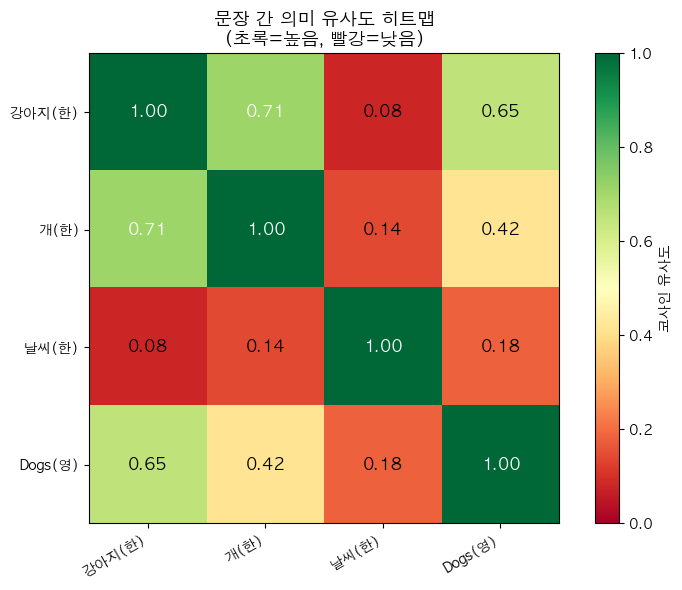


💡 영어 문장 S4가 한국어 강아지 문장 S1과 높은 유사도를 보입니다!
   다국어 임베딩 모델은 언어를 넘어 의미를 이해합니다.


In [12]:
# 유사도 히트맵 시각화
fig, ax = plt.subplots(figsize=(8, 6))

short_labels = [
    "강아지(한)",
    "개(한)",
    "날씨(한)",
    "Dogs(영)"
]

im = ax.imshow(sim_matrix, cmap='RdYlGn', vmin=0, vmax=1)

ax.set_xticks(range(len(short_labels)))
ax.set_yticks(range(len(short_labels)))
ax.set_xticklabels(short_labels, rotation=30, ha='right', fontsize=10)
ax.set_yticklabels(short_labels, fontsize=10)

# 숫자 표시
for i in range(len(sample_sentences)):
    for j in range(len(sample_sentences)):
        text = ax.text(j, i, f"{sim_matrix[i, j]:.2f}",
                      ha="center", va="center", fontsize=12, fontweight='bold',
                      color="white" if sim_matrix[i, j] > 0.7 else "black")

plt.colorbar(im, ax=ax, label='코사인 유사도')
ax.set_title('문장 간 의미 유사도 히트맵\n(초록=높음, 빨강=낮음)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('similarity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💡 영어 문장 S4가 한국어 강아지 문장 S1과 높은 유사도를 보입니다!")
print("   다국어 임베딩 모델은 언어를 넘어 의미를 이해합니다.")

### 🔬 임베딩 벡터, 안을 들여다보면?

임베딩 벡터가 실제로 어떻게 생겼는지 눈으로 확인해봅시다.  
비슷한 문장의 벡터는 패턴이 비슷하고, 다른 문장은 패턴이 완전히 다릅니다.

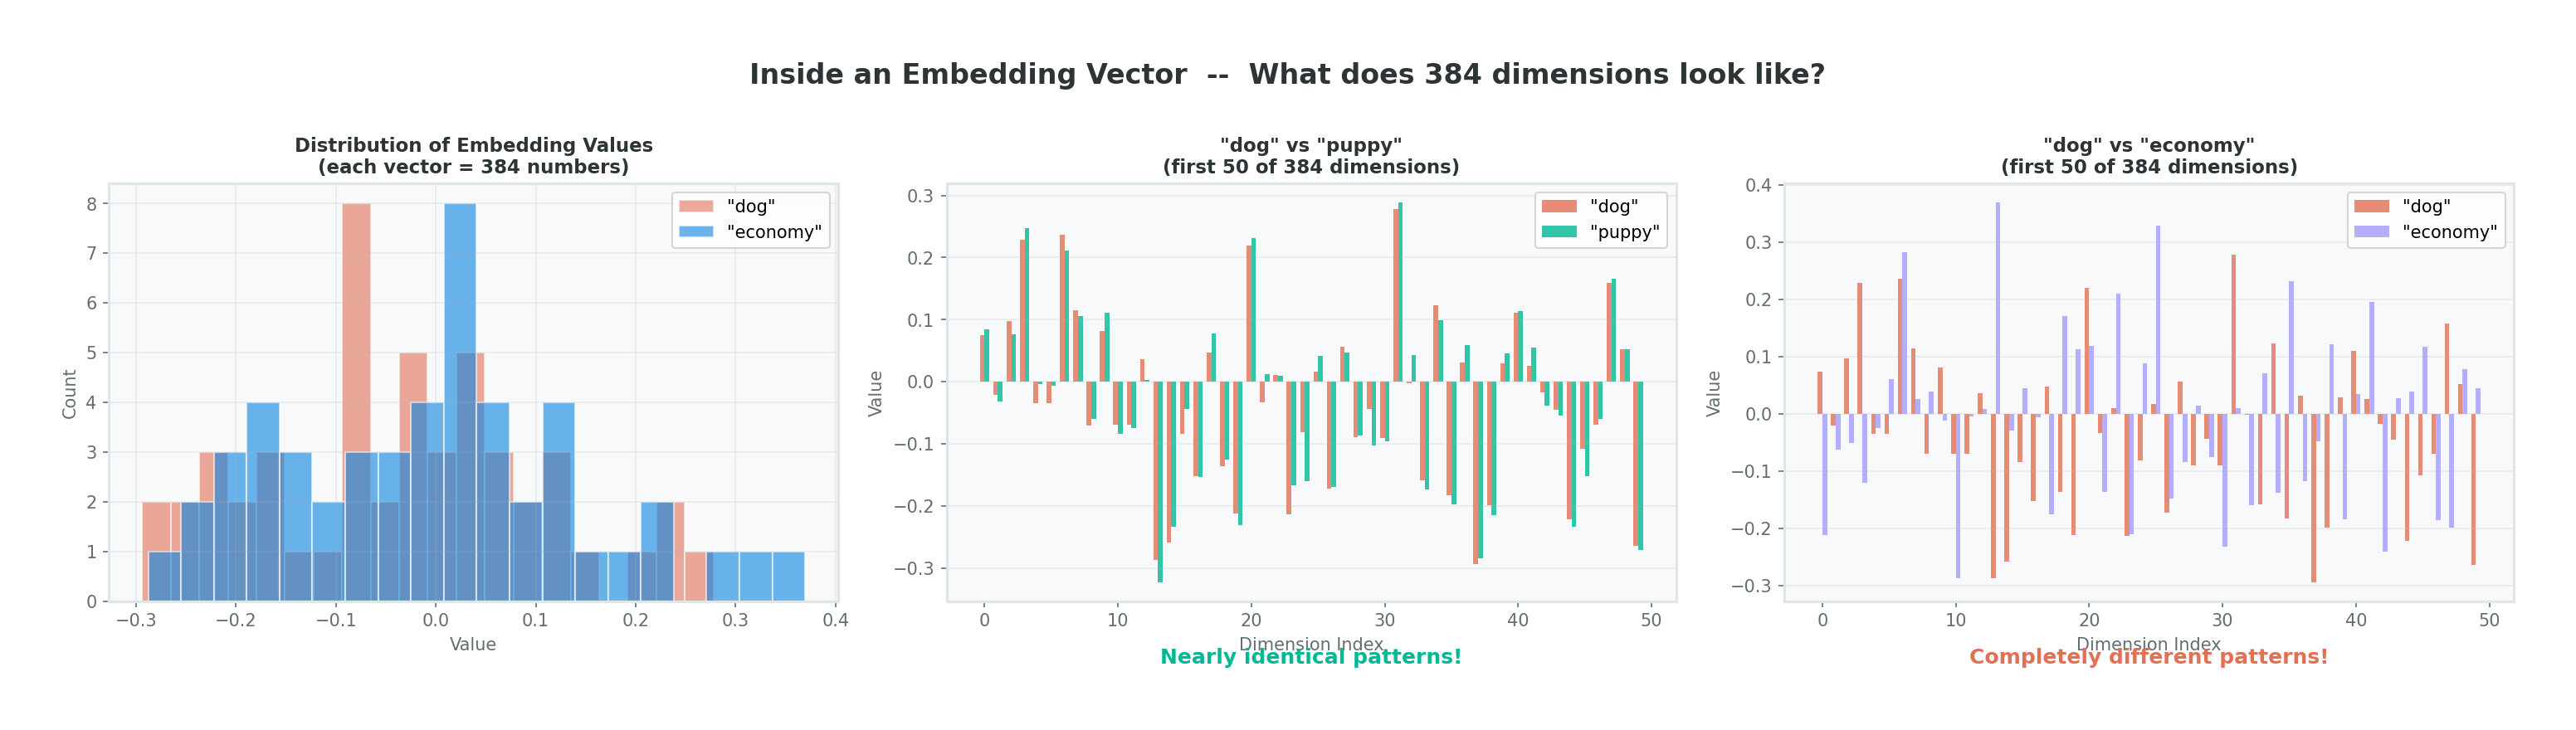

=== 임베딩 벡터 내부 비교 ===

처음 20개 차원의 값 비교:
  A: 강아지+공원:
    [+0.369, +0.135, -0.142, +0.040, -0.163, -0.056, +0.311, +0.002, +0.092, -0.031, ...]
  B: 개+잔디밭:
    [+0.243, +0.169, -0.401, +0.163, +0.339, +0.022, -0.123, -0.252, +0.094, -0.207, ...]
  C: 주식+하락:
    [+0.014, +0.023, +0.044, +0.019, -0.039, -0.115, +0.167, -0.002, +0.082, +0.056, ...]



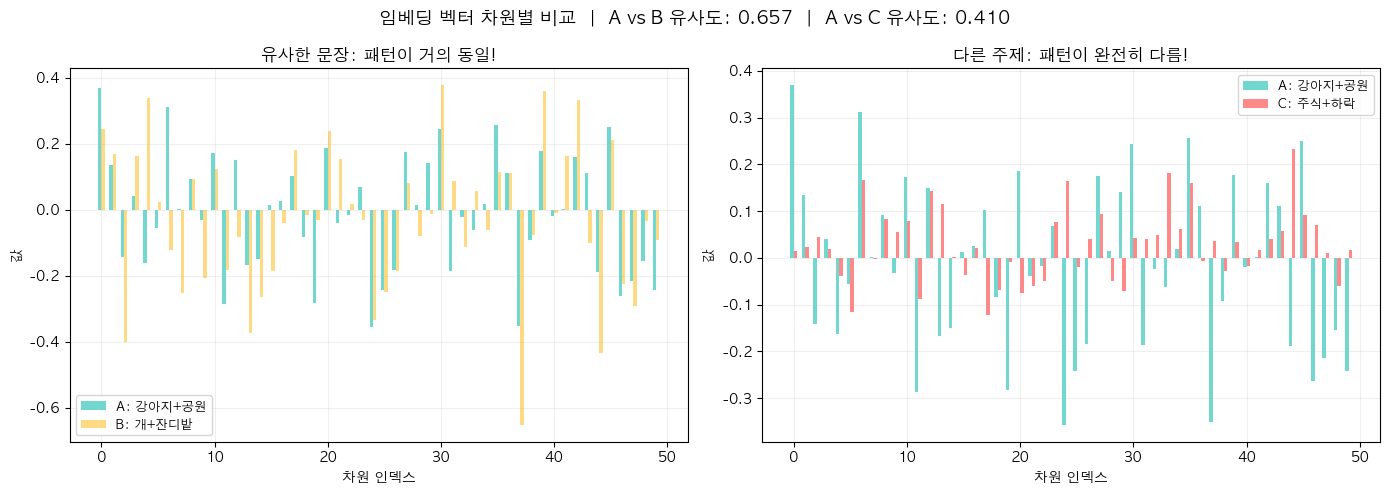


💡 "강아지+공원" vs "개+잔디밭" → 패턴 비슷 → 유사도 0.657
   "강아지+공원" vs "주식+하락"   → 패턴 다름 → 유사도 0.410


In [13]:
# 실제 임베딩 벡터 내부를 직접 비교해보기
print('=== 임베딩 벡터 내부 비교 ===')
print()

compare_sentences = [
    '강아지가 공원에서 뛰어놀고 있다',     # 문장 A
    '개가 잔디밭에서 달리고 있다',          # 문장 B (유사)
    '주식 시장이 오늘 크게 하락했다',       # 문장 C (다름)
]

compare_embeddings = model_local.encode(compare_sentences)

# 처음 20개 차원만 비교
print('처음 20개 차원의 값 비교:')
labels = ['A: 강아지+공원', 'B: 개+잔디밭', 'C: 주식+하락']
for label, emb in zip(labels, compare_embeddings):
    vals = ', '.join([f'{v:+.3f}' for v in emb[:10]])
    print(f'  {label}:')
    print(f'    [{vals}, ...]')
print()

# 차원별 패턴 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dims = range(50)
ax = axes[0]
ax.bar([d-0.15 for d in dims], compare_embeddings[0][:50], width=0.3,
       color='#4ECDC4', alpha=0.8, label=labels[0])
ax.bar([d+0.15 for d in dims], compare_embeddings[1][:50], width=0.3,
       color='#FFD166', alpha=0.8, label=labels[1])
ax.set_title('유사한 문장: 패턴이 거의 동일!', fontsize=12, fontweight='bold')
ax.set_xlabel('차원 인덱스'); ax.set_ylabel('값')
ax.legend(fontsize=9); ax.grid(True, alpha=0.2)

ax = axes[1]
ax.bar([d-0.15 for d in dims], compare_embeddings[0][:50], width=0.3,
       color='#4ECDC4', alpha=0.8, label=labels[0])
ax.bar([d+0.15 for d in dims], compare_embeddings[2][:50], width=0.3,
       color='#FF6B6B', alpha=0.8, label=labels[2])
ax.set_title('다른 주제: 패턴이 완전히 다름!', fontsize=12, fontweight='bold')
ax.set_xlabel('차원 인덱스'); ax.set_ylabel('값')
ax.legend(fontsize=9); ax.grid(True, alpha=0.2)

sim_ab = cosine_similarity([compare_embeddings[0]], [compare_embeddings[1]])[0][0]
sim_ac = cosine_similarity([compare_embeddings[0]], [compare_embeddings[2]])[0][0]
plt.suptitle(f'임베딩 벡터 차원별 비교  |  A vs B 유사도: {sim_ab:.3f}  |  A vs C 유사도: {sim_ac:.3f}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'\n💡 "강아지+공원" vs "개+잔디밭" → 패턴 비슷 → 유사도 {sim_ab:.3f}')
print(f'   "강아지+공원" vs "주식+하락"   → 패턴 다름 → 유사도 {sim_ac:.3f}')

---
# Part 4. 활용 1 — 의미 기반 유사도 검색 (Semantic Search)

## 🔍 기존 검색 vs 의미 기반 검색

| 구분 | 기존 키워드 검색 | 의미 기반 검색 |
|------|-----------------|----------------|
| 방식 | 정확한 단어 일치 | 의미적 유사도 |
| 예시 | "강아지" 검색 시 "강아지"만 찾음 | "강아지" 검색 시 "반려견", "puppy"도 찾음 |
| 한계 | 동의어, 유사어 놓침 | 의미 파악 가능 |

## 🛠 구현 과정

1. **문서 준비**: 검색할 문서들을 임베딩으로 변환 (사전 처리)
2. **질의 처리**: 검색 질문도 임베딩으로 변환
3. **유사도 계산**: 질의 vs 모든 문서 코사인 유사도 계산
4. **결과 반환**: 유사도 높은 순서로 정렬

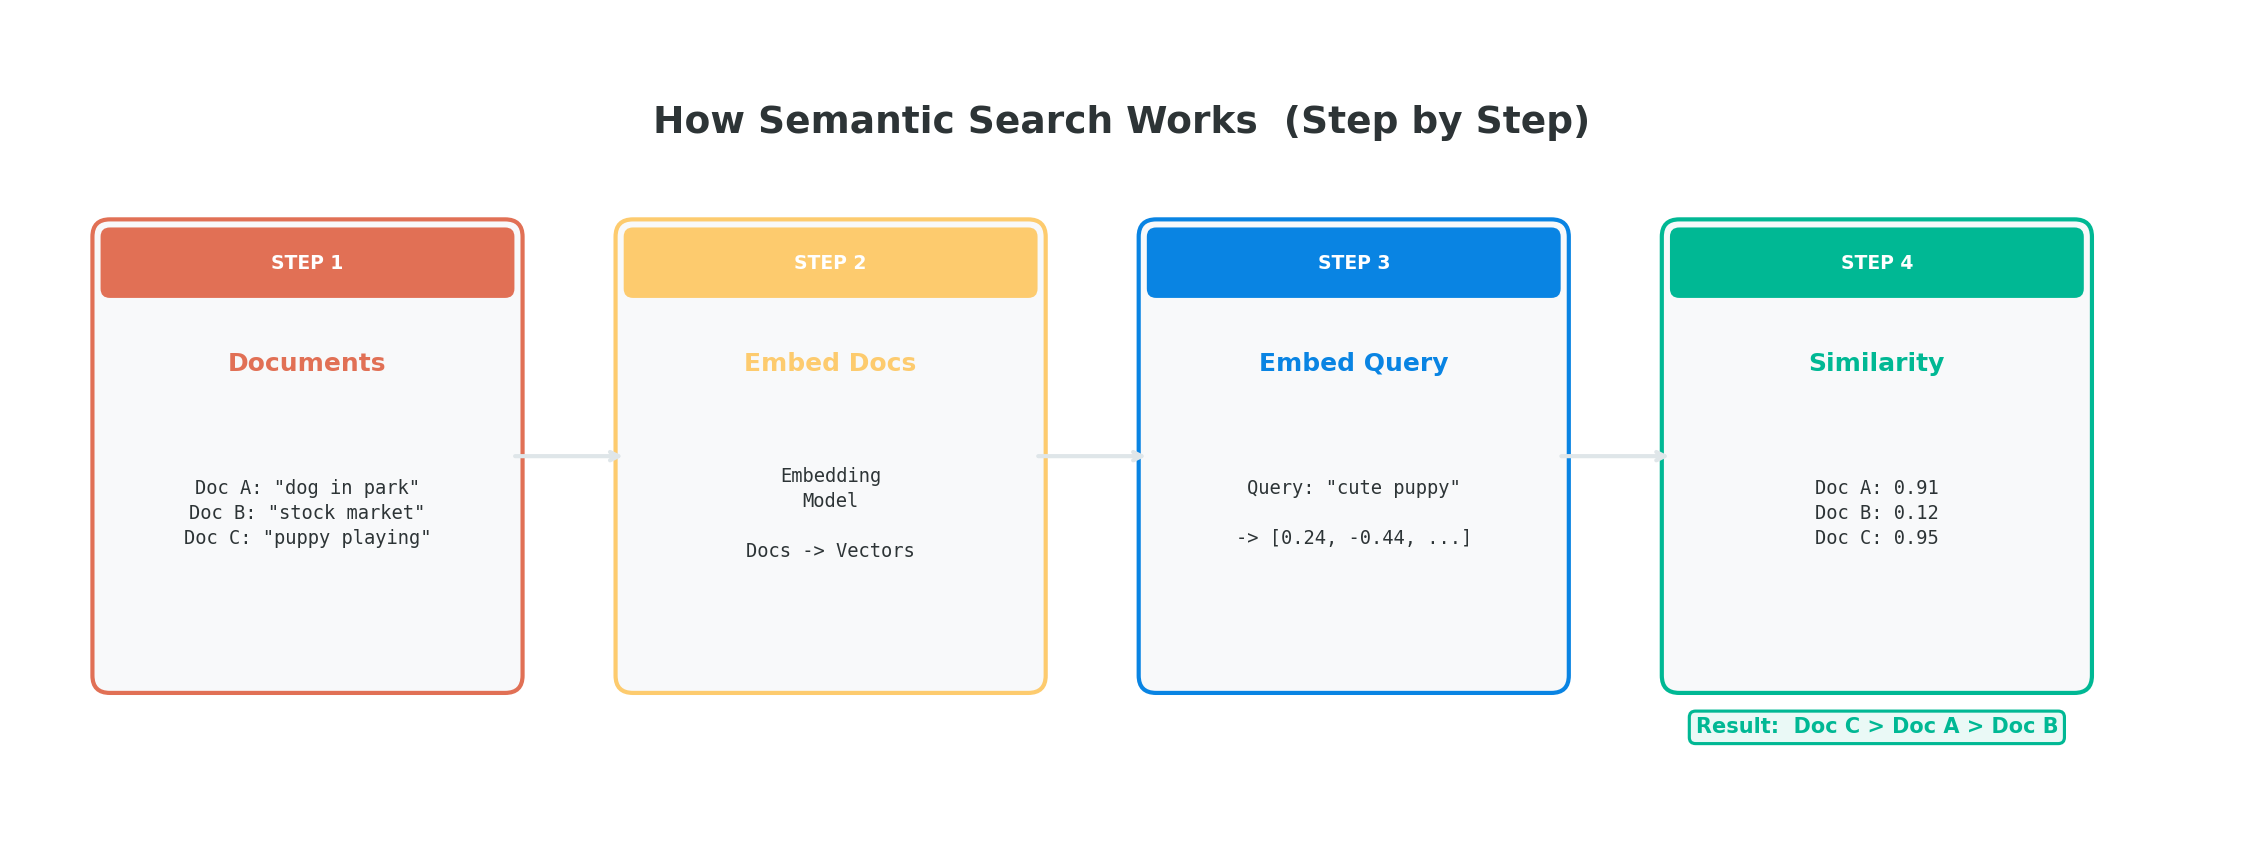

*▲ 시맨틱 서치 4단계 흐름: 문서 임베딩 → 질의 임베딩 → 유사도 계산 → 결과 정렬*

In [14]:
# 의미 기반 검색 시스템 구축
print("=== 의미 기반 검색 시스템 ===")
print()

# 검색 대상 문서 준비 (뉴스 헤드라인 예시)
documents = [
    "삼성전자, 차세대 갤럭시 스마트폰 공개 — 혁신적인 AI 카메라 탑재",
    "애플, 아이폰 16 시리즈 발표 — 더 강력해진 칩과 배터리 성능",
    "국내 전기차 시장 급성장 — 현대차·기아 글로벌 판매 기록 갱신",
    "테슬라 자율주행 기술 업데이트 — FSD 12 버전 출시",
    "주식시장 변동성 확대 — 미국 연준 금리 결정에 시장 주목",
    "코스피, 반도체 강세에 2600선 회복 — 외국인 순매수 지속",
    "손흥민, 리그 8호 골 폭발 — 토트넘 3-0 완승",
    "2024 파리 올림픽 개막 — 한국 선수단 첫날 금메달 획득",
    "메타, 라마 4 오픈소스 공개 — 무료로 쓸 수 있는 최강 AI 모델",
    "구글 제미나이 2.0 업데이트 — 코딩·수학 능력 혁신",
    "기후변화 대응 국제 협약 체결 — 120개국 탄소중립 목표 합의",
    "서울 부동산 시장 안정세 — 아파트 거래량 소폭 증가",
]

print(f"📄 문서 수: {len(documents)}개")
print("\n문서 목록:")
for i, doc in enumerate(documents):
    print(f"  [{i+1:2d}] {doc}")

# 모든 문서를 임베딩으로 변환 (실제로는 이 과정이 미리 되어 있어야 함)
print("\n🔄 문서 임베딩 생성 중...")
doc_embeddings = model_local.encode(documents)
print(f"✅ 완료! 각 문서 → {doc_embeddings.shape[1]}차원 벡터")

=== 의미 기반 검색 시스템 ===

📄 문서 수: 12개

문서 목록:
  [ 1] 삼성전자, 차세대 갤럭시 스마트폰 공개 — 혁신적인 AI 카메라 탑재
  [ 2] 애플, 아이폰 16 시리즈 발표 — 더 강력해진 칩과 배터리 성능
  [ 3] 국내 전기차 시장 급성장 — 현대차·기아 글로벌 판매 기록 갱신
  [ 4] 테슬라 자율주행 기술 업데이트 — FSD 12 버전 출시
  [ 5] 주식시장 변동성 확대 — 미국 연준 금리 결정에 시장 주목
  [ 6] 코스피, 반도체 강세에 2600선 회복 — 외국인 순매수 지속
  [ 7] 손흥민, 리그 8호 골 폭발 — 토트넘 3-0 완승
  [ 8] 2024 파리 올림픽 개막 — 한국 선수단 첫날 금메달 획득
  [ 9] 메타, 라마 4 오픈소스 공개 — 무료로 쓸 수 있는 최강 AI 모델
  [10] 구글 제미나이 2.0 업데이트 — 코딩·수학 능력 혁신
  [11] 기후변화 대응 국제 협약 체결 — 120개국 탄소중립 목표 합의
  [12] 서울 부동산 시장 안정세 — 아파트 거래량 소폭 증가

🔄 문서 임베딩 생성 중...
✅ 완료! 각 문서 → 384차원 벡터


In [15]:
def semantic_search(query, documents, doc_embeddings, model, top_k=3):
    """
    의미 기반 검색 함수
    
    Args:
        query: 검색 질문
        documents: 검색 대상 문서 리스트
        doc_embeddings: 문서 임베딩 (사전 계산)
        model: 임베딩 모델
        top_k: 반환할 결과 수
    """
    # 1. 질의를 임베딩으로 변환
    query_embedding = model.encode([query])
    
    # 2. 코사인 유사도 계산
    similarities = cosine_similarity(query_embedding, doc_embeddings)[0]
    
    # 3. 유사도 높은 순으로 정렬
    sorted_indices = np.argsort(similarities)[::-1]
    
    # 4. 결과 반환
    results = []
    for idx in sorted_indices[:top_k]:
        results.append({
            "rank": len(results) + 1,
            "document": documents[idx],
            "similarity": similarities[idx],
            "index": idx
        })
    return results


# 다양한 검색 쿼리 테스트
queries = [
    "AI 기술 발전",
    "스포츠 경기 결과",
    "자동차 관련 소식",
    "투자와 금융",
]

for query in queries:
    print(f"\n{'='*60}")
    print(f"🔍 검색어: '{query}'")
    print(f"{'='*60}")
    
    results = semantic_search(query, documents, doc_embeddings, model_local, top_k=3)
    
    for result in results:
        bar = "▓" * int(result['similarity'] * 20)
        print(f"  {result['rank']}위 (유사도: {result['similarity']:.3f}) {bar}")
        print(f"      {result['document']}")
    print()


🔍 검색어: 'AI 기술 발전'
  1위 (유사도: 0.700) ▓▓▓▓▓▓▓▓▓▓▓▓▓▓
      메타, 라마 4 오픈소스 공개 — 무료로 쓸 수 있는 최강 AI 모델
  2위 (유사도: 0.480) ▓▓▓▓▓▓▓▓▓
      삼성전자, 차세대 갤럭시 스마트폰 공개 — 혁신적인 AI 카메라 탑재
  3위 (유사도: 0.428) ▓▓▓▓▓▓▓▓
      구글 제미나이 2.0 업데이트 — 코딩·수학 능력 혁신


🔍 검색어: '스포츠 경기 결과'
  1위 (유사도: 0.694) ▓▓▓▓▓▓▓▓▓▓▓▓▓
      손흥민, 리그 8호 골 폭발 — 토트넘 3-0 완승
  2위 (유사도: 0.428) ▓▓▓▓▓▓▓▓
      2024 파리 올림픽 개막 — 한국 선수단 첫날 금메달 획득
  3위 (유사도: 0.295) ▓▓▓▓▓
      구글 제미나이 2.0 업데이트 — 코딩·수학 능력 혁신


🔍 검색어: '자동차 관련 소식'
  1위 (유사도: 0.561) ▓▓▓▓▓▓▓▓▓▓▓
      국내 전기차 시장 급성장 — 현대차·기아 글로벌 판매 기록 갱신
  2위 (유사도: 0.374) ▓▓▓▓▓▓▓
      손흥민, 리그 8호 골 폭발 — 토트넘 3-0 완승
  3위 (유사도: 0.331) ▓▓▓▓▓▓
      테슬라 자율주행 기술 업데이트 — FSD 12 버전 출시


🔍 검색어: '투자와 금융'
  1위 (유사도: 0.546) ▓▓▓▓▓▓▓▓▓▓
      주식시장 변동성 확대 — 미국 연준 금리 결정에 시장 주목
  2위 (유사도: 0.453) ▓▓▓▓▓▓▓▓▓
      서울 부동산 시장 안정세 — 아파트 거래량 소폭 증가
  3위 (유사도: 0.272) ▓▓▓▓▓
      코스피, 반도체 강세에 2600선 회복 — 외국인 순매수 지속



In [16]:
# 🎯 직접 검색해보세요!
print("=== 직접 검색 체험 ===")
print()

# 아래 query를 원하는 것으로 바꿔서 실행해보세요!
my_query = "핸드폰 신제품"  # ← 여기를 바꿔보세요

print(f"검색어: '{my_query}'")
print()

results = semantic_search(my_query, documents, doc_embeddings, model_local, top_k=4)

for result in results:
    print(f"  {result['rank']}위 (유사도: {result['similarity']:.3f})")
    print(f"      📰 {result['document']}")
    print()

print("💡 Tip: '핸드폰 신제품'을 검색해도 '스마트폰'이 포함된 기사가 나옵니다!")
print("   임베딩이 의미를 이해하기 때문입니다.")

=== 직접 검색 체험 ===

검색어: '핸드폰 신제품'

  1위 (유사도: 0.531)
      📰 삼성전자, 차세대 갤럭시 스마트폰 공개 — 혁신적인 AI 카메라 탑재

  2위 (유사도: 0.446)
      📰 테슬라 자율주행 기술 업데이트 — FSD 12 버전 출시

  3위 (유사도: 0.359)
      📰 구글 제미나이 2.0 업데이트 — 코딩·수학 능력 혁신

  4위 (유사도: 0.319)
      📰 애플, 아이폰 16 시리즈 발표 — 더 강력해진 칩과 배터리 성능

💡 Tip: '핸드폰 신제품'을 검색해도 '스마트폰'이 포함된 기사가 나옵니다!
   임베딩이 의미를 이해하기 때문입니다.


### 검색 결과는 어떻게 평가할까?

의미 기반 검색에서 **코사인 유사도**가 곧 검색 품질입니다.

```
코사인 유사도 = 두 벡터의 방향 일치도

  1.0  →  완전히 같은 의미
  0.7+ →  매우 관련 있는 문서
  0.5+ →  어느 정도 관련 있음
  0.3  →  약간의 관련성
  0.0  →  무관
```

> 위 검색 결과에서 1위와 3위의 유사도 차이를 비교해보세요.  
> 유사도가 높을수록 쿼리 의도에 가까운 문서입니다.  
> 동의어/유의어("핸드폰" → "스마트폰")도 검색되는 것이 임베딩 검색의 핵심 장점입니다.


---
# Part 5. 활용 2 — 텍스트 클러스터링

## 클러스터링이란?

비슷한 것들을 **자동으로 그룹**으로 묶는 기술입니다.
임베딩 + 클러스터링 = 의미적으로 비슷한 텍스트들을 자동 분류!

### 활용 사례
- 고객 피드백 자동 분류
- 뉴스 기사 토픽 분류
- 비슷한 제품 리뷰 그룹화

---

## 클러스터링 평가 지표

클러스터링이 "잘 됐는지"를 측정하는 지표 3가지를 소개합니다.

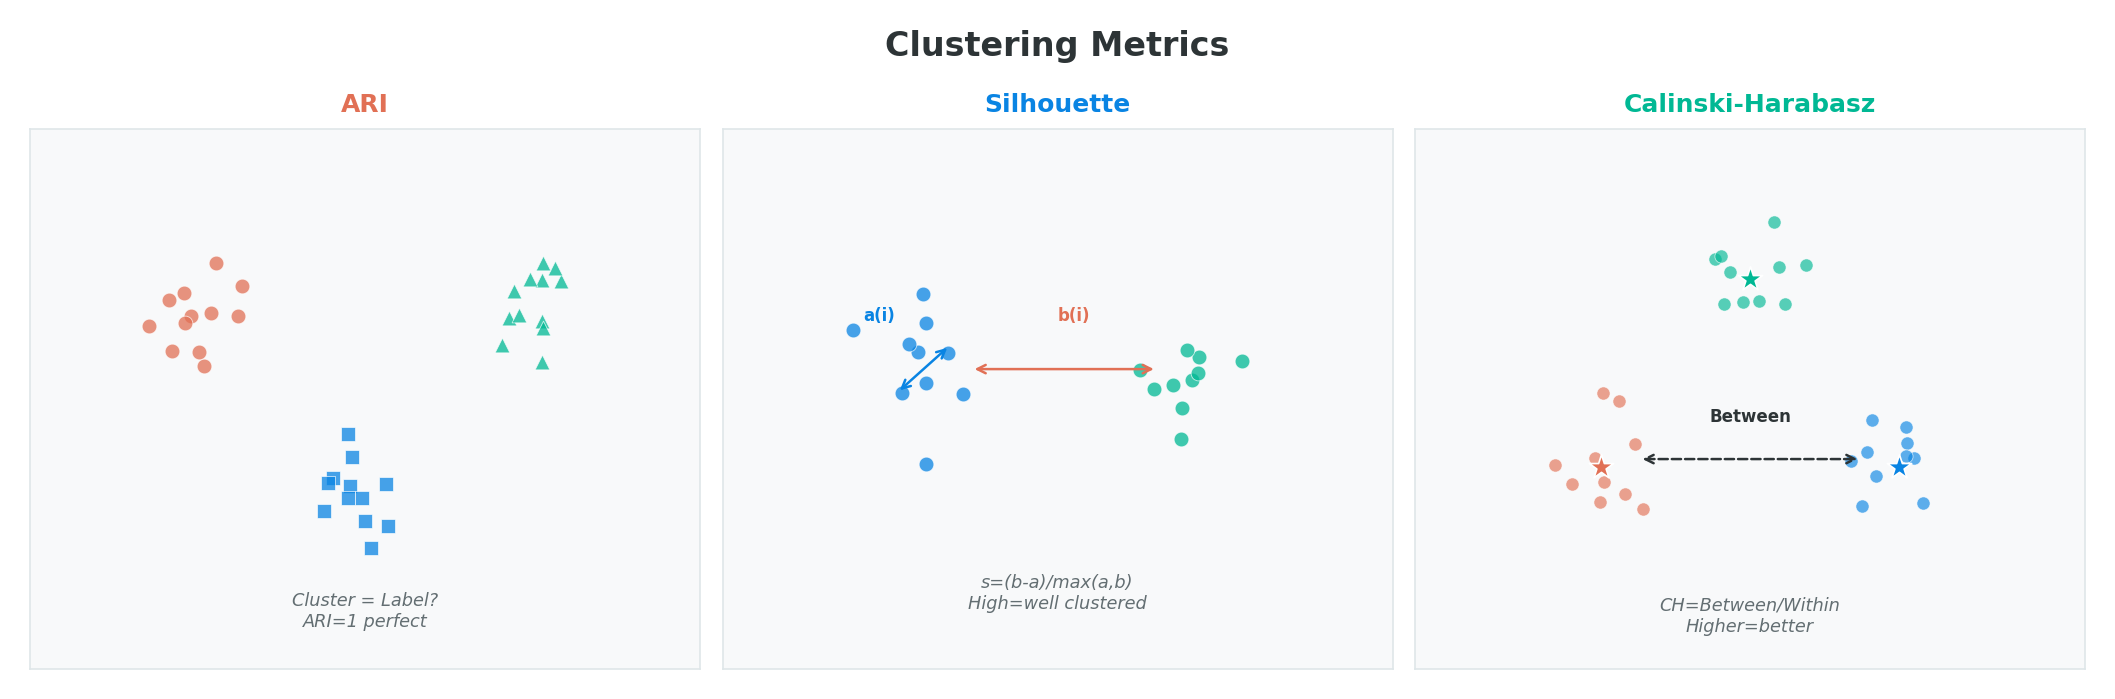

*▲ 왼쪽부터: ARI(클러스터=정답 일치율), 실루엣(내부 밀집 vs 외부 분리), CH(클러스터 간/내 분산 비율)*

---

### 1) ARI (Adjusted Rand Index) — "정답과 얼마나 일치하는가?"

```
ARI = (관찰된 일치 - 우연에 의한 기대 일치) / (최대 일치 - 우연에 의한 기대 일치)

  ARI = 1.0 : 클러스터 = 정답 (완벽)
  ARI > 0.6 : 잘 분리됨
  ARI ≈ 0.0 : 무작위 수준
  ARI < 0.0 : 랜덤보다 못함
```

> 정답 레이블이 있을 때만 사용 가능.
> "모델이 정답 없이도 주제를 구분할 수 있는가?"를 확인하는 데 최적.

### 2) 실루엣 점수 (Silhouette Score) — "뭉침 vs 분리"

```
s(i) = (b(i) - a(i)) / max(a(i), b(i))

  a(i) : 같은 클러스터 내 평균 거리  → 작을수록 좋음 (잘 뭉침)
  b(i) : 가장 가까운 다른 클러스터와의 평균 거리 → 클수록 좋음 (잘 분리됨)

  범위: -1 ~ 1
    ≈ 1  : 본인 클러스터에 잘 속함
    ≈ 0  : 경계에 위치 (애매함)
    < 0  : 잘못된 클러스터에 할당됨
  기준: 0.5↑ 강함 / 0.25↑ 보통 / 0.25↓ 약함
```

> 정답 레이블 없이도 계산 가능.
> 임베딩 공간에서는 클러스터가 구(球) 형태가 아니라서 낮게 나오는 경향이 있음.

### 3) Calinski-Harabasz Score (CH) — "클러스터 간 분산 / 클러스터 내 분산"

```
CH = (클러스터 간 분산 × (N - K)) / (클러스터 내 분산 × (K - 1))

  N = 전체 샘플 수,  K = 클러스터 수
```

> 절대값 기준이 없음 → **K를 바꿔가며 상대 비교**할 때 유용.
> 높을수록 클러스터가 잘 분리된 것.

---

| 지표 | 정답 필요 | 범위 | 언제 쓰나 |
|------|----------|------|----------|
| **ARI** | O | -1 ~ 1 | 정답과 비교할 때 (주 지표) |
| **실루엣** | X | -1 ~ 1 | 내부 밀집도 확인 (참고) |
| **CH** | X | 0 ~ ∞ | K 최적값 찾을 때 (비교용) |


In [17]:
from sklearn.cluster import KMeans

print('=== 텍스트 클러스터링 ===')
print()

# 다양한 주제의 문장들 (레이블 없이 — 클러스터링이 알아서 분류)
texts_to_cluster = [
    # AI/기술
    'ChatGPT가 글쓰기를 도와줍니다.',
    '딥러닝 모델로 이미지를 인식합니다.',
    '자연어 처리 기술이 빠르게 발전하고 있습니다.',
    '머신러닝 알고리즘을 코딩으로 구현합니다.',
    # 음식
    '오늘 저녁은 김치찌개를 끓였습니다.',
    '치킨과 맥주가 정말 잘 어울립니다.',
    '삼겹살을 구워 먹으니 맛있습니다.',
    '된장찌개와 밥이 한 끼 식사의 기본입니다.',
    # 스포츠
    '손흥민이 결승골을 넣었습니다.',
    '야구 경기에서 홈런이 터졌습니다.',
    '축구 월드컵 예선 경기가 열렸습니다.',
    '농구팀이 챔피언십 우승을 차지했습니다.',
    # 여행
    '파리 에펠탑 앞에서 사진을 찍었습니다.',
    '뉴욕 타임스퀘어에서 야경을 감상했습니다.',
    '제주도 한라산에서 등산을 했습니다.',
    '도쿄 시부야에서 쇼핑을 즐겼습니다.',
]

actual_topics = (
    ['AI/기술']*4 + ['음식']*4 + ['스포츠']*4 + ['여행']*4
)

# 임베딩 생성
cluster_embeddings = model_local.encode(texts_to_cluster)
print(f'총 {len(texts_to_cluster)}개 문장 임베딩 완료')

# K-Means 클러스터링
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(cluster_embeddings)

print(f'\nK-Means 클러스터링 결과 (4개 그룹):')
print()
for c in range(4):
    idxs = [i for i, l in enumerate(cluster_labels) if l == c]
    print('=' * 50)
    print(f'클러스터 {c+1}:')
    for idx in idxs:
        print(f'   - {texts_to_cluster[idx]}')
        print(f'     (실제 주제: {actual_topics[idx]})')


=== 텍스트 클러스터링 ===

총 16개 문장 임베딩 완료

K-Means 클러스터링 결과 (4개 그룹):

클러스터 1:
   - ChatGPT가 글쓰기를 도와줍니다.
     (실제 주제: AI/기술)
   - 딥러닝 모델로 이미지를 인식합니다.
     (실제 주제: AI/기술)
   - 자연어 처리 기술이 빠르게 발전하고 있습니다.
     (실제 주제: AI/기술)
   - 머신러닝 알고리즘을 코딩으로 구현합니다.
     (실제 주제: AI/기술)
클러스터 2:
   - 파리 에펠탑 앞에서 사진을 찍었습니다.
     (실제 주제: 여행)
   - 뉴욕 타임스퀘어에서 야경을 감상했습니다.
     (실제 주제: 여행)
   - 도쿄 시부야에서 쇼핑을 즐겼습니다.
     (실제 주제: 여행)
클러스터 3:
   - 오늘 저녁은 김치찌개를 끓였습니다.
     (실제 주제: 음식)
   - 치킨과 맥주가 정말 잘 어울립니다.
     (실제 주제: 음식)
   - 삼겹살을 구워 먹으니 맛있습니다.
     (실제 주제: 음식)
   - 된장찌개와 밥이 한 끼 식사의 기본입니다.
     (실제 주제: 음식)
   - 손흥민이 결승골을 넣었습니다.
     (실제 주제: 스포츠)
   - 축구 월드컵 예선 경기가 열렸습니다.
     (실제 주제: 스포츠)
   - 농구팀이 챔피언십 우승을 차지했습니다.
     (실제 주제: 스포츠)
   - 제주도 한라산에서 등산을 했습니다.
     (실제 주제: 여행)
클러스터 4:
   - 야구 경기에서 홈런이 터졌습니다.
     (실제 주제: 스포츠)


In [18]:
# 클러스터링 평가 — 3가지 지표
from sklearn.metrics import adjusted_rand_score, silhouette_score, calinski_harabasz_score

# 실제 레이블을 숫자로 변환
topic_to_num = {'AI/기술': 0, '음식': 1, '스포츠': 2, '여행': 3}
true_labels = [topic_to_num[t] for t in actual_topics]

# 3가지 지표 계산
ari = adjusted_rand_score(true_labels, cluster_labels)
sil = silhouette_score(cluster_embeddings, cluster_labels)
ch  = calinski_harabasz_score(cluster_embeddings, cluster_labels)

print('클러스터링 평가 결과')
print(f'  ARI (정답 일치율)      : {ari:.3f}')
print(f'  실루엣 (밀집/분리)     : {sil:.3f}')
print(f'  Calinski-Harabasz (CH) : {ch:.1f}')
print()

print('[ 해석 ]')
# ARI
if ari > 0.8:
    print(f'  ARI {ari:.2f} → 클러스터가 실제 토픽과 거의 일치')
elif ari > 0.5:
    print(f'  ARI {ari:.2f} → 대체로 잘 분리, 일부 경계 모호')
else:
    print(f'  ARI {ari:.2f} → 토픽 복원이 어려움')
    print('    원인: 16개 문장은 클러스터링에 충분하지 않은 양')
    print('    + 토픽 간 어휘 겹침 가능 (예: 여행지에서 음식 언급)')

# 실루엣
if sil > 0.5:
    print(f'  실루엣 {sil:.2f} → 클러스터 내부 밀집도 강함')
elif sil > 0.25:
    print(f'  실루엣 {sil:.2f} → 클러스터 구조 보통')
else:
    print(f'  실루엣 {sil:.2f} → 클러스터 내부 밀집도 약함')
    print('    원인: 임베딩 공간에서 클러스터가 구 형태가 아닌 비선형 분포')

# CH
print(f'  CH {ch:.0f} → 절대값보다 K를 바꿔가며 비교할 때 의미 있음')
print()
print('  Tip: embedding_practice.ipynb에서 위키피디아 198개 문서로')
print('  실험하면 ARI 0.99를 달성합니다. 데이터가 많고 토픽이 명확할수록 좋아집니다.')


클러스터링 평가 결과
  ARI (정답 일치율)      : 0.459
  실루엣 (밀집/분리)     : 0.093
  Calinski-Harabasz (CH) : 2.3

[ 해석 ]
  ARI 0.46 → 토픽 복원이 어려움
    원인: 16개 문장은 클러스터링에 충분하지 않은 양
    + 토픽 간 어휘 겹침 가능 (예: 여행지에서 음식 언급)
  실루엣 0.09 → 클러스터 내부 밀집도 약함
    원인: 임베딩 공간에서 클러스터가 구 형태가 아닌 비선형 분포
  CH 2 → 절대값보다 K를 바꿔가며 비교할 때 의미 있음

  Tip: embedding_practice.ipynb에서 위키피디아 198개 문서로
  실험하면 ARI 0.99를 달성합니다. 데이터가 많고 토픽이 명확할수록 좋아집니다.


In [19]:
from sklearn.manifold import TSNE
import sklearn

print('=== t-SNE 임베딩 시각화 ===')
print()

all_texts = [
    # 🤖 AI/기술 (6개)
    'ChatGPT가 글쓰기를 도와줍니다.',
    '딥러닝으로 이미지를 인식합니다.',
    'GPT-4는 강력한 언어 모델입니다.',
    '파이썬으로 머신러닝을 공부합니다.',
    '임베딩 벡터로 텍스트를 분석합니다.',
    '자연어 처리 기술이 발전하고 있습니다.',
    # 🍕 음식 (6개)
    '오늘 저녁은 김치찌개를 끓였습니다.',
    '치킨과 맥주가 잘 어울립니다.',
    '삼겹살 구이가 맛있습니다.',
    '된장찌개와 흰밥이 최고입니다.',
    '파스타를 집에서 만들었습니다.',
    '초밥과 라멘을 함께 먹었습니다.',
    # ⚽ 스포츠 (6개)
    '손흥민이 멋진 골을 넣었습니다.',
    '야구 경기에서 홈런이 나왔습니다.',
    '농구팀이 우승을 차지했습니다.',
    '테니스 선수가 그랜드슬램을 달성했습니다.',
    '수영 선수가 세계 기록을 깼습니다.',
    '골프 대회에서 한국 선수가 우승했습니다.',
    # ✈ 여행 (6개)
    '제주도 한라산을 등반했습니다.',
    '파리 에펠탑을 배경으로 사진 찍었습니다.',
    '도쿄에서 스시와 라멘을 먹었습니다.',
    '뉴욕 타임스퀘어의 야경이 화려합니다.',
    '바르셀로나 가우디 건축물을 감상했습니다.',
    '싱가포르 마리나베이샌즈에서 수영했습니다.',
]
all_labels = ['AI/기술']*6 + ['음식']*6 + ['스포츠']*6 + ['여행']*6

print('임베딩 생성 중...')
all_embeddings = model_local.encode(all_texts)
print(f'✅ {len(all_texts)}개 문장 → {all_embeddings.shape[1]}차원 완료')

# sklearn 버전 호환성: 1.2+ → max_iter, 이전 → n_iter
sk_ver = tuple(int(x) for x in sklearn.__version__.split('.')[:2])
tsne_params = dict(n_components=2, perplexity=7, random_state=42)
if sk_ver >= (1, 2):
    tsne_params['max_iter'] = 1000
else:
    tsne_params['n_iter'] = 1000

print('t-SNE 2차원 압축 중...')
tsne = TSNE(**tsne_params)
embeddings_2d = tsne.fit_transform(all_embeddings)
print(f'✅ {all_embeddings.shape[1]}차원 → 2차원 완료')


=== t-SNE 임베딩 시각화 ===

임베딩 생성 중...
✅ 24개 문장 → 384차원 완료
t-SNE 2차원 압축 중...
✅ 384차원 → 2차원 완료


---

## 시각화의 주의사항

t-SNE/UMAP은 **탐색적 시각화 도구**이지 평가 지표가 아닙니다.

| 방법 | 장점 | 한계 |
|------|------|------|
| **t-SNE** | 지역 구조(가까운 점) 보존에 강함 | 클러스터 간 거리는 의미 없음, 실행마다 결과 다름 |
| **UMAP** | 전역+지역 구조 모두 보존, 속도 빠름 | 하이퍼파라미터에 민감 |

> 2D 그래프에서 클러스터가 겹쳐 보여도 **768차원 원래 공간에서는 잘 분리**되어 있을 수 있습니다.  
> 시각화는 직관적 확인용이고, 정량적 평가는 ARI/실루엣/CH로 해야 합니다.

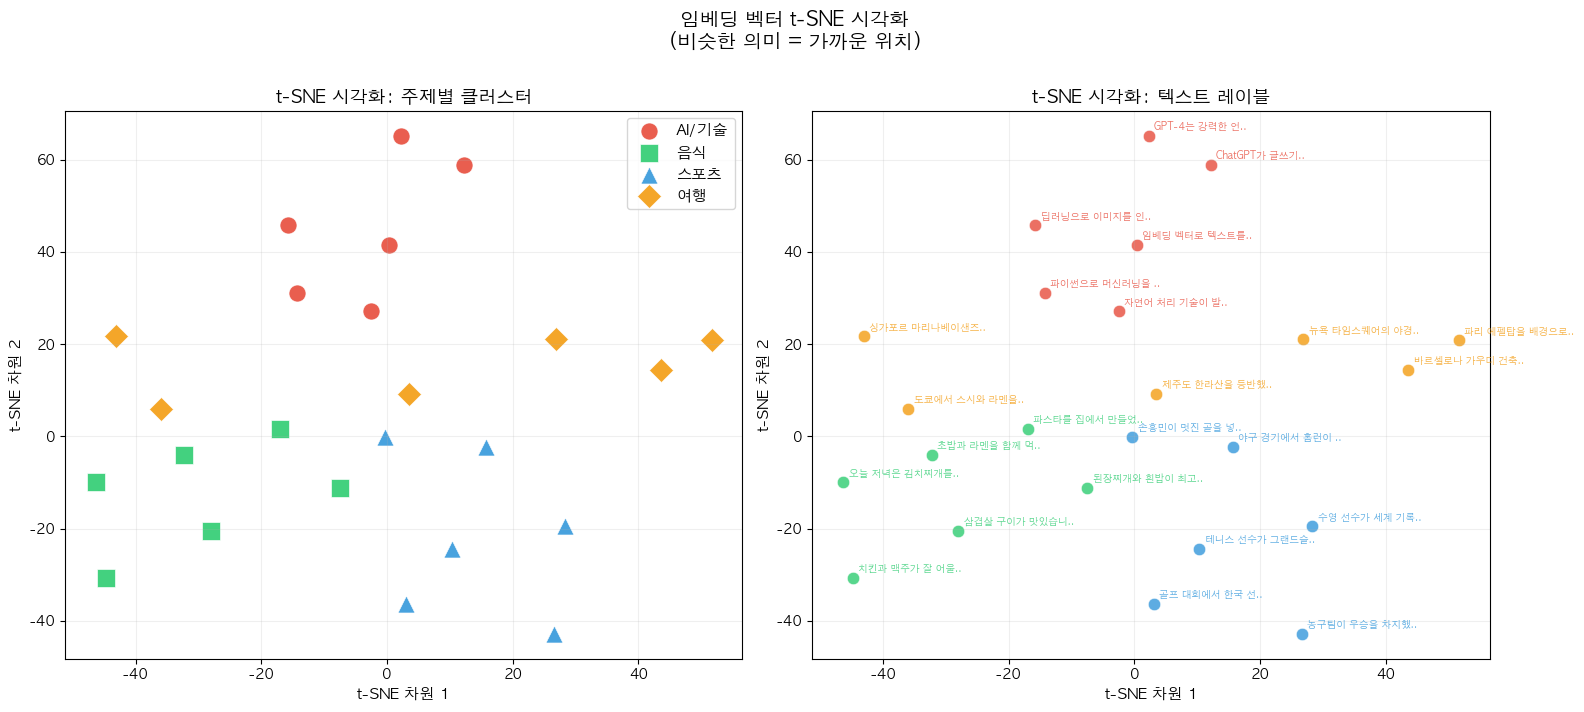


💡 같은 주제의 문장들이 공간에서 가까이 모여 있습니다!
   임베딩이 의미를 잘 포착하고 있다는 증거입니다.


In [20]:
# t-SNE 결과 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 색상 및 마커 설정
topic_styles = {
    "AI/기술":  {"color": "#E74C3C", "marker": "o"},
    "음식":     {"color": "#2ECC71", "marker": "s"},
    "스포츠":   {"color": "#3498DB", "marker": "^"},
    "여행":     {"color": "#F39C12", "marker": "D"},
}

unique_labels = list(dict.fromkeys(all_labels))

# 왼쪽: 카테고리별 색상
ax1 = axes[0]
for topic in unique_labels:
    style = topic_styles[topic]
    mask = [l == topic for l in all_labels]
    x = embeddings_2d[mask, 0]
    y = embeddings_2d[mask, 1]
    ax1.scatter(x, y, c=style['color'], marker=style['marker'],
               s=150, label=topic,
               edgecolors='white', linewidth=0.5, alpha=0.9)

ax1.set_title('t-SNE 시각화: 주제별 클러스터', fontsize=13, fontweight='bold')
ax1.legend(fontsize=11, loc='best')
ax1.set_xlabel('t-SNE 차원 1', fontsize=11)
ax1.set_ylabel('t-SNE 차원 2', fontsize=11)
ax1.grid(True, alpha=0.2)

# 오른쪽: 텍스트 레이블 표시
ax2 = axes[1]
for i, (text, topic) in enumerate(zip(all_texts, all_labels)):
    style = topic_styles[topic]
    x, y = embeddings_2d[i, 0], embeddings_2d[i, 1]
    ax2.scatter(x, y, c=style['color'], s=80,
               edgecolors='white', linewidth=0.5, alpha=0.8)
    # 텍스트 일부만 표시 (처음 10자)
    short_text = text[:12] + ".." if len(text) > 12 else text
    ax2.annotate(short_text, (x, y),
               textcoords="offset points", xytext=(4, 4),
               fontsize=7, alpha=0.8, color=style['color'])

ax2.set_title('t-SNE 시각화: 텍스트 레이블', fontsize=13, fontweight='bold')
ax2.set_xlabel('t-SNE 차원 1', fontsize=11)
ax2.set_ylabel('t-SNE 차원 2', fontsize=11)
ax2.grid(True, alpha=0.2)

plt.suptitle('임베딩 벡터 t-SNE 시각화\n(비슷한 의미 = 가까운 위치)', 
            fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('tsne_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💡 같은 주제의 문장들이 공간에서 가까이 모여 있습니다!")
print("   임베딩이 의미를 잘 포착하고 있다는 증거입니다.")

---
# 🎓 정리 및 요약

## 오늘 배운 것들

### 1️⃣ 개념 이해
| 기술 | 설명 | 한계 |
|------|------|------|
| **인코딩** | 글자에 번호 붙이기 | 의미 없음 |
| **원-핫 인코딩** | 단어 사전에 0/1 표시 | 유사도 파악 불가 |
| **임베딩** | 의미를 담은 수치 벡터 | 의미 연산 가능! |

### 2️⃣ 수학 기초
- **벡터**: 여러 숫자의 순서 있는 목록 → 공간의 한 점
- **코사인 유사도**: 두 벡터의 방향 유사도 (-1 ~ +1)

### 3️⃣ 실습 모델
- **sentence-transformers**: 오픈소스, 무료, Colab/로컬 실행 가능
- `paraphrase-multilingual-MiniLM-L12-v2` → 한국어 포함 다국어 지원

### 4️⃣ 활용 사례
- **의미 기반 검색**: 키워드가 달라도 의미로 검색 (코사인 유사도로 순위 매김)
- **클러스터링**: 비슷한 텍스트 자동 분류 (ARI/실루엣/CH로 평가)
- **t-SNE 시각화**: 고차원 임베딩을 눈으로 확인 (탐색용, 정량 평가는 별도)

### 5️⃣ 평가 지표 요약
| 지표 | 용도 | 정답 필요 | 기준 |
|------|------|----------|------|
| **코사인 유사도** | 검색 순위 | X | 0.7↑ 매우 관련 / 0.5↑ 관련 |
| **ARI** | 클러스터 vs 정답 | O | 0.6↑ 잘 분리 / 1.0 완벽 |
| **실루엣** | 클러스터 밀집도 | X | 0.25↑ 보통 / 0.5↑ 강함 |
| **CH** | K 비교 | X | 높을수록 좋음 (상대 비교) |

---

## 🚀 다음 단계 (추가 학습)

- **RAG**: 임베딩 검색 + LLM 답변 생성
- **벡터 데이터베이스**: FAISS, Chroma, Pinecone으로 대규모 검색
- **OpenAI 임베딩**: `text-embedding-3-small/large` (API 키 필요)
- **파인튜닝**: 특정 도메인에 맞게 임베딩 모델 조정

---

## 📚 참고 자료

- [sentence-transformers 공식 문서](https://www.sbert.net/)
- [Hugging Face 모델 허브](https://huggingface.co/models?pipeline_tag=sentence-similarity)
- [Word2Vec 논문 (Mikolov et al., 2013)](https://arxiv.org/abs/1301.3666)
- [t-SNE 논문](https://jmlr.org/papers/v9/vandermaaten08a.html)

---

> 🎉 **수고하셨습니다!** 이제 여러분도 임베딩의 개념과 활용법을 알게 되었습니다.  
> 실제 프로젝트에 바로 적용해보세요!

In [21]:
# 🎯 보너스: 나만의 문장 임베딩 체험
print("=" * 60)
print("🎯 보너스: 나만의 문장 의미 비교")
print("=" * 60)
print()

# 아래 문장들을 마음대로 바꿔서 실험해보세요!
my_sentences = [
    "오늘 회사에서 힘든 일이 있었다.",
    "직장에서 어려운 상황을 겪었다.",      # ← 비슷한 의미?
    "저녁에 운동을 하러 헬스장에 갔다.",   # ← 다른 주제?
    "Today was a tough day at work.",      # ← 영어로 같은 의미?
]

my_embeddings = model_local.encode(my_sentences)
my_sim_matrix = cosine_similarity(my_embeddings)

print("문장 목록:")
for i, s in enumerate(my_sentences):
    print(f"  [{i+1}] {s}")

print("\n유사도 결과:")
for i in range(len(my_sentences)):
    for j in range(i+1, len(my_sentences)):
        sim = my_sim_matrix[i, j]
        level = "🔴 낮음" if sim < 0.4 else ("🟡 중간" if sim < 0.7 else "🟢 높음")
        print(f"  [{i+1}] vs [{j+1}]: {sim:.3f} {level}")

print()
print("💡 직접 문장을 바꿔서 임베딩이 어떻게 반응하는지 실험해보세요!")

🎯 보너스: 나만의 문장 의미 비교

문장 목록:
  [1] 오늘 회사에서 힘든 일이 있었다.
  [2] 직장에서 어려운 상황을 겪었다.
  [3] 저녁에 운동을 하러 헬스장에 갔다.
  [4] Today was a tough day at work.

유사도 결과:
  [1] vs [2]: 0.854 🟢 높음
  [1] vs [3]: 0.164 🔴 낮음
  [1] vs [4]: 0.866 🟢 높음
  [2] vs [3]: 0.241 🔴 낮음
  [2] vs [4]: 0.725 🟢 높음
  [3] vs [4]: 0.233 🔴 낮음

💡 직접 문장을 바꿔서 임베딩이 어떻게 반응하는지 실험해보세요!
